In [19]:
# Cell 1 — PICS database setup
# Uses the same PhysioNet access method as completed Notebook 03

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb

from scipy.signal import butter, sosfiltfilt, find_peaks

# PICS database
PICS_PATH = "https://physionet.org/files/picsdb/1.0.0/"

# Sampling frequencies established in Notebook 03
ECG_FS = 250
RESP_FS = 500

print("Libraries imported successfully.")
print("PICS database path:", PICS_PATH)
print("ECG sampling frequency:", ECG_FS, "Hz")
print("Respiration sampling frequency:", RESP_FS, "Hz")

Libraries imported successfully.
PICS database path: https://physionet.org/files/picsdb/1.0.0/
ECG sampling frequency: 250 Hz
Respiration sampling frequency: 500 Hz


In [20]:
# Cell 1 — PICS multi-infant validation setup

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb

from scipy.signal import butter, sosfiltfilt, find_peaks
from pathlib import Path

# --------------------------------------------------
# Project paths
# --------------------------------------------------

PROJECT_ROOT = Path("..").resolve()
REPORTS_DIR = PROJECT_ROOT / "reports"

# --------------------------------------------------
# PICS database
# --------------------------------------------------

PICS_PATH = "https://physionet.org/files/picsdb/1.0.0/"

# All ten PICS infants
INFANTS = list(range(1, 11))

print("Libraries imported successfully.")
print()
print("PICS database:", PICS_PATH)
print("Infants to validate:", INFANTS)
print("Number of infants:", len(INFANTS))
print()
print("Project root:", PROJECT_ROOT)
print("Reports directory:", REPORTS_DIR)

Libraries imported successfully.

PICS database: https://physionet.org/files/picsdb/1.0.0/
Infants to validate: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Number of infants: 10

Project root: C:\Users\Mohamed Rizwan M J\Desktop\neonatal-apnea-monitor
Reports directory: C:\Users\Mohamed Rizwan M J\Desktop\neonatal-apnea-monitor\reports


In [21]:
# Cell 2 — Inspect PICS record headers for all 10 infants

record_info = []

for infant in INFANTS:
    print(f"\n--- Infant {infant} ---")

    ecg_record = f"infant{infant}_ecg"
    resp_record = f"infant{infant}_resp"

    try:
        ecg_header = wfdb.rdheader(
            ecg_record,
            pn_dir="picsdb/1.0.0"
        )

        resp_header = wfdb.rdheader(
            resp_record,
            pn_dir="picsdb/1.0.0"
        )

        info = {
            "infant": infant,
            "ecg_fs": ecg_header.fs,
            "ecg_samples": ecg_header.sig_len,
            "ecg_channels": ecg_header.n_sig,
            "resp_fs": resp_header.fs,
            "resp_samples": resp_header.sig_len,
            "resp_channels": resp_header.n_sig,
        }

        record_info.append(info)

        print("ECG:")
        print("  Sampling frequency:", ecg_header.fs, "Hz")
        print("  Samples:", ecg_header.sig_len)
        print("  Channels:", ecg_header.n_sig)

        print("Respiration:")
        print("  Sampling frequency:", resp_header.fs, "Hz")
        print("  Samples:", resp_header.sig_len)
        print("  Channels:", resp_header.n_sig)

    except Exception as e:
        print("ERROR:", repr(e))

record_info_df = pd.DataFrame(record_info)

print("\n\n===== PICS RECORD SUMMARY =====")
display(record_info_df)


--- Infant 1 ---
ECG:
  Sampling frequency: 250 Hz
  Samples: 41052191
  Channels: 1
Respiration:
  Sampling frequency: 500 Hz
  Samples: 82122000
  Channels: 1

--- Infant 2 ---
ECG:
  Sampling frequency: 500 Hz
  Samples: 78916000
  Channels: 1
Respiration:
  Sampling frequency: 50 Hz
  Samples: 7891433
  Channels: 1

--- Infant 3 ---
ECG:
  Sampling frequency: 500 Hz
  Samples: 78684614
  Channels: 1
Respiration:
  Sampling frequency: 50 Hz
  Samples: 7868296
  Channels: 1

--- Infant 4 ---
ECG:
  Sampling frequency: 500 Hz
  Samples: 84208000
  Channels: 1
Respiration:
  Sampling frequency: 50 Hz
  Samples: 8420800
  Channels: 1

--- Infant 5 ---
ECG:
  Sampling frequency: 250 Hz
  Samples: 43878723
  Channels: 1
Respiration:
  Sampling frequency: 50 Hz
  Samples: 8955598
  Channels: 1

--- Infant 6 ---
ECG:
  Sampling frequency: 500 Hz
  Samples: 87492197
  Channels: 1
Respiration:
  Sampling frequency: 50 Hz
  Samples: 8749057
  Channels: 1

--- Infant 7 ---
ECG:
  Sampling freq

,infant,ecg_fs,ecg_samples,ecg_channels,resp_fs,resp_samples,resp_channels
0,1,250,41052191,1,500,82122000,1
1,2,500,78916000,1,50,7891433,1
2,3,500,78684614,1,50,7868296,1
3,4,500,84208000,1,50,8420800,1
4,5,250,43878723,1,50,8955598,1
5,6,500,87492197,1,50,8749057,1
6,7,500,36604500,1,50,3660288,1
7,8,500,44288000,1,50,4428613,1
8,9,500,126569088,1,50,12656784,1
9,10,500,85083254,1,50,8508154,1


In [22]:
# Cell 4 — Inspect bradycardia annotations for all 10 infants

annotation_info = []

for infant in INFANTS:
    print(f"\n--- Infant {infant} ---")

    try:
        annotations = wfdb.rdann(
            f"infant{infant}_ecg",
            "atr",
            pn_dir="picsdb/1.0.0"
        )

        symbols = pd.Series(annotations.symbol).value_counts()

        annotation_info.append({
            "infant": infant,
            "annotation_count": len(annotations.sample),
            "first_annotation_s": (
                annotations.sample[0] /
                record_info_df.loc[
                    record_info_df["infant"] == infant,
                    "ecg_fs"
                ].iloc[0]
            ),
            "last_annotation_s": (
                annotations.sample[-1] /
                record_info_df.loc[
                    record_info_df["infant"] == infant,
                    "ecg_fs"
                ].iloc[0]
            ),
            "unique_symbols": ", ".join(sorted(symbols.index.astype(str)))
        })

        print("Total annotations:", len(annotations.sample))
        print("Annotation symbols:")
        print(symbols.to_string())

    except Exception as e:
        print("ERROR:", repr(e))

annotation_info_df = pd.DataFrame(annotation_info)

print("\n" + "=" * 70)
print("PICS ANNOTATION SUMMARY")
print("=" * 70)

display(annotation_info_df)


--- Infant 1 ---
Total annotations: 77
Annotation symbols:
[    77

--- Infant 2 ---
Total annotations: 72
Annotation symbols:
[    72

--- Infant 3 ---
Total annotations: 80
Annotation symbols:
[    80

--- Infant 4 ---
Total annotations: 66
Annotation symbols:
[    66

--- Infant 5 ---
Total annotations: 72
Annotation symbols:
[    72

--- Infant 6 ---
Total annotations: 56
Annotation symbols:
[    56

--- Infant 7 ---
Total annotations: 34
Annotation symbols:
[    34

--- Infant 8 ---
Total annotations: 28
Annotation symbols:
[    28

--- Infant 9 ---
Total annotations: 97
Annotation symbols:
[    97

--- Infant 10 ---
Total annotations: 40
Annotation symbols:
[    40

PICS ANNOTATION SUMMARY


,infant,annotation_count,first_annotation_s,last_annotation_s,unique_symbols
0,1,77,1971.372,160831.724,[
1,2,72,2235.784,157602.718,[
2,3,80,9.618,156512.520,[
3,4,66,4790.382,166163.988,[
4,5,72,3650.344,172399.524,[
5,6,56,1407.802,172827.138,[
6,7,34,231.870,69235.848,[
7,8,28,641.458,88160.688,[
8,9,97,6900.050,252590.872,[
9,10,40,813.164,157401.282,[


In [23]:
# Cell 5 — Verify annotation symbols across all 10 PICS infants

symbol_summary = []

for infant in INFANTS:
    annotations = wfdb.rdann(
        f"infant{infant}_ecg",
        "atr",
        pn_dir="picsdb/1.0.0"
    )

    unique_symbols = sorted(set(annotations.symbol))

    symbol_summary.append({
        "infant": infant,
        "unique_symbols": unique_symbols,
        "number_of_unique_symbols": len(unique_symbols),
        "total_annotations": len(annotations.sample)
    })

symbol_summary_df = pd.DataFrame(symbol_summary)

print("PICS annotation symbol verification")
print("=" * 70)

display(symbol_summary_df)

PICS annotation symbol verification


,infant,unique_symbols,number_of_unique_symbols,total_annotations
0,1,[[],1,77
1,2,[[],1,72
2,3,[[],1,80
3,4,[[],1,66
4,5,[[],1,72
5,6,[[],1,56
6,7,[[],1,34
7,8,[[],1,28
8,9,[[],1,97
9,10,[[],1,40


In [24]:
# Cell 6 — Build multi-infant annotated event table

all_events = []

for infant in INFANTS:

    # Read ECG header to get the correct sampling frequency
    ecg_header = wfdb.rdheader(
        f"infant{infant}_ecg",
        pn_dir="picsdb/1.0.0"
    )

    # Read bradycardia annotations
    annotations = wfdb.rdann(
        f"infant{infant}_ecg",
        "atr",
        pn_dir="picsdb/1.0.0"
    )

    ecg_fs = ecg_header.fs

    for event_number, (sample, symbol) in enumerate(
        zip(annotations.sample, annotations.symbol),
        start=1
    ):
        all_events.append({
            "infant": infant,
            "event_number": event_number,
            "annotation_sample": int(sample),
            "event_time_s": sample / ecg_fs,
            "annotation_symbol": symbol,
            "ecg_fs": ecg_fs
        })

events_df = pd.DataFrame(all_events)

print("Multi-infant annotated event table created.")
print()
print("Total events:", len(events_df))
print("Total infants:", events_df["infant"].nunique())
print()

print("Events per infant:")
print(events_df.groupby("infant").size())

print("\nFirst 15 events:")
display(events_df.head(15))

Multi-infant annotated event table created.

Total events: 622
Total infants: 10

Events per infant:
infant
1     77
2     72
3     80
4     66
5     72
6     56
7     34
8     28
9     97
10    40
dtype: int64

First 15 events:


,infant,event_number,annotation_sample,event_time_s,annotation_symbol,ecg_fs
0,1,1,492843,1971.372,[,250
1,1,2,864128,3456.512,[,250
2,1,3,984499,3937.996,[,250
3,1,4,1208687,4834.748,[,250
4,1,5,1924068,7696.272,[,250
5,1,6,2061665,8246.660,[,250
6,1,7,3277415,13109.660,[,250
7,1,8,3671197,14684.788,[,250
8,1,9,4092936,16371.744,[,250
9,1,10,4279525,17118.100,[,250


In [25]:
# Cell 7 — Validated event-detection parameters from Notebook 03

# ECG filtering
ECG_LOW = 0.5
ECG_HIGH = 40.0
ECG_FILTER_ORDER = 4

# Respiration filtering
RESP_LOW_APNEA = 0.03
RESP_HIGH_APNEA = 2.0
RESP_FILTER_ORDER = 4

# Respiratory suppression criteria
MIN_RESP_DURATION = 3.0

# Event-centered analysis window
EVENT_WINDOW_BEFORE = 30.0
EVENT_WINDOW_AFTER = 30.0

# QRS matching tolerance used during validation
QRS_TOLERANCE = 0.050

print("Validated event-detection parameters loaded.")
print()
print("ECG filter       :", ECG_LOW, "-", ECG_HIGH, "Hz")
print("Respiration      :", RESP_LOW_APNEA, "-", RESP_HIGH_APNEA, "Hz")
print("Resp filter order:", RESP_FILTER_ORDER)
print("Min resp duration:", MIN_RESP_DURATION, "s")
print("Event window     :", EVENT_WINDOW_BEFORE, "s before /",
      EVENT_WINDOW_AFTER, "s after")
print("QRS tolerance    :", QRS_TOLERANCE, "s")

Validated event-detection parameters loaded.

ECG filter       : 0.5 - 40.0 Hz
Respiration      : 0.03 - 2.0 Hz
Resp filter order: 4
Min resp duration: 3.0 s
Event window     : 30.0 s before / 30.0 s after
QRS tolerance    : 0.05 s


In [26]:
# Cell 8 — Sampling-rate-aware SOS filter builders

def build_ecg_filter(ecg_fs):
    """
    Build the validated ECG bandpass filter.

    Parameters
    ----------
    ecg_fs : float
        ECG sampling frequency in Hz.

    Returns
    -------
    sos : ndarray
        Second-order-section filter coefficients.
    """
    return butter(
        ECG_FILTER_ORDER,
        [ECG_LOW, ECG_HIGH],
        btype="bandpass",
        fs=ecg_fs,
        output="sos"
    )


def build_resp_filter(resp_fs):
    """
    Build the validated apnea-oriented respiration bandpass filter.

    Parameters
    ----------
    resp_fs : float
        Respiration sampling frequency in Hz.

    Returns
    -------
    sos : ndarray
        Second-order-section filter coefficients.
    """
    return butter(
        RESP_FILTER_ORDER,
        [RESP_LOW_APNEA, RESP_HIGH_APNEA],
        btype="bandpass",
        fs=resp_fs,
        output="sos"
    )


print("Sampling-rate-aware filter builders created successfully.")

# Verify the filters using Infant 1's actual sampling rates
infant1_ecg_fs = record_info_df.loc[
    record_info_df["infant"] == 1, "ecg_fs"
].iloc[0]

infant1_resp_fs = record_info_df.loc[
    record_info_df["infant"] == 1, "resp_fs"
].iloc[0]

ecg_sos_test = build_ecg_filter(infant1_ecg_fs)
resp_sos_test = build_resp_filter(infant1_resp_fs)

print()
print("Infant 1 ECG filter:")
print("  Sampling frequency:", infant1_ecg_fs, "Hz")
print("  SOS shape:", ecg_sos_test.shape)

print()
print("Infant 1 respiration filter:")
print("  Sampling frequency:", infant1_resp_fs, "Hz")
print("  SOS shape:", resp_sos_test.shape)

Sampling-rate-aware filter builders created successfully.

Infant 1 ECG filter:
  Sampling frequency: 250 Hz
  SOS shape: (4, 6)

Infant 1 respiration filter:
  Sampling frequency: 500 Hz
  SOS shape: (4, 6)


In [27]:
# Cell 9 — Exact ECG R-peak detection from Notebook 03

def detect_r_peaks(ecg_signal, ecg_fs):
    """
    Detect R-peaks using the exact method used in Notebook 03.

    The ECG event signal is used directly without additional
    filtering in this event-detection step.
    """

    peaks, properties = find_peaks(
        ecg_signal,
        distance=int(0.30 * ecg_fs),
        prominence=0.3
    )

    return peaks, properties


print("Exact Notebook 03 ECG R-peak detector loaded successfully.")
print("ECG filtering in event detector: none")
print("Minimum peak distance: 0.30 s")
print("Peak prominence: 0.3")

Exact Notebook 03 ECG R-peak detector loaded successfully.
ECG filtering in event detector: none
Minimum peak distance: 0.30 s
Peak prominence: 0.3


In [36]:
# Cell 10 — Infant 1 Event 2 regression test
# Sampling rate is obtained from record_info_df
# This avoids dependence on ECG_FS_TEST

INFANT_TEST = 1
EVENT_TEST = 2
EVENT_ONSET = 3456.512

# Get sampling rates from the multi-infant record table
test_info = record_info_df[
    record_info_df["infant"] == INFANT_TEST
].iloc[0]

ecg_fs_test = float(test_info["ecg_fs"])
resp_fs_test = float(test_info["resp_fs"])

window_start = EVENT_ONSET - EVENT_WINDOW_BEFORE
window_end = EVENT_ONSET + EVENT_WINDOW_AFTER

ecg_start = int(round(window_start * ecg_fs_test))
ecg_end = int(round(window_end * ecg_fs_test))

resp_start = int(round(window_start * resp_fs_test))
resp_end = int(round(window_end * resp_fs_test))

print("=" * 70)
print("INFANT 1 EVENT 2 REGRESSION TEST")
print("=" * 70)

print("Infant:", INFANT_TEST)
print("Event:", EVENT_TEST)
print("Event onset:", EVENT_ONSET, "s")
print()
print("ECG sampling frequency:", ecg_fs_test, "Hz")
print("Respiration sampling frequency:", resp_fs_test, "Hz")
print()
print("ECG sample range:", ecg_start, "to", ecg_end)
print("Respiration sample range:", resp_start, "to", resp_end)

# Load ECG
ecg_record = wfdb.rdrecord(
    f"infant{INFANT_TEST}_ecg",
    pn_dir="picsdb/1.0.0",
    sampfrom=ecg_start,
    sampto=ecg_end
)

ecg_signal = ecg_record.p_signal[:, 0]

# Load respiration
resp_record = wfdb.rdrecord(
    f"infant{INFANT_TEST}_resp",
    pn_dir="picsdb/1.0.0",
    sampfrom=resp_start,
    sampto=resp_end
)

resp_signal = resp_record.p_signal[:, 0]

print()
print("Loaded ECG samples:", len(ecg_signal))
print("Loaded respiration samples:", len(resp_signal))

# Detect R-peaks using the validated detector
ecg_peaks, ecg_peak_properties = detect_r_peaks(
    ecg_signal,
    ecg_fs_test
)

ecg_peak_times = ecg_peaks / ecg_fs_test

print()
print("R-peaks detected:", len(ecg_peaks))

# Calculate RR and HR
if len(ecg_peak_times) > 1:

    rr_event = np.diff(ecg_peak_times)
    hr_event = 60.0 / rr_event
    hr_times = ecg_peak_times[1:]

else:

    rr_event = np.array([])
    hr_event = np.array([])
    hr_times = np.array([])

print("RR intervals detected:", len(rr_event))

if len(hr_event) > 0:

    print("Mean HR:", np.mean(hr_event), "BPM")
    print("Minimum HR:", 60.0 / np.max(rr_event), "BPM")
    print("Maximum HR:", 60.0 / np.min(rr_event), "BPM")

# Detect bradycardia
brady_runs_test = detect_bradycardia_runs(
    hr_times,
    hr_event,
    threshold=100.0
)

print()
print("=" * 70)
print("BRADYCARDIA RUNS")
print("=" * 70)

display(brady_runs_test)

# Filter respiration
filtered_resp = filter_respiration_signal(
    resp_signal,
    resp_fs_test
)

# Detect low-respiration runs
resp_runs_test, resp_rms_test, resp_threshold_test = (
    detect_low_respiration_runs(
        filtered_resp,
        resp_fs_test,
        threshold_factor=0.20,
        rms_window_seconds=2.0,
        minimum_duration=MIN_RESP_DURATION
    )
)

print()
print("=" * 70)
print("RESPIRATION SUPPRESSION RUNS")
print("=" * 70)

display(resp_runs_test)

print("Respiration RMS threshold:", resp_threshold_test)

# Calculate overlap
overlap_test = calculate_overlap(
    resp_runs_test,
    brady_runs_test
)

print()
print("=" * 70)
print("RESPIRATION-BRADYCARDIA OVERLAPS")
print("=" * 70)

display(overlap_test)

# Classify
classification_test = classify_events(
    resp_runs_test,
    brady_runs_test,
    apnea_duration_threshold=20.0
)

print()
print("=" * 70)
print("EVENT 2 CLASSIFICATIONS")
print("=" * 70)

display(classification_test)

INFANT 1 EVENT 2 REGRESSION TEST
Infant: 1
Event: 2
Event onset: 3456.512 s

ECG sampling frequency: 250.0 Hz
Respiration sampling frequency: 500.0 Hz

ECG sample range: 856628 to 871628
Respiration sample range: 1713256 to 1743256

Loaded ECG samples: 15000
Loaded respiration samples: 30000

R-peaks detected: 129
RR intervals detected: 128
Mean HR: 136.72267835809885 BPM
Minimum HR: 41.208791208791325 BPM
Maximum HR: 185.1851851851863 BPM

BRADYCARDIA RUNS


,start,end,duration
0,30.672,39.648,8.976
1,42.312,48.024,5.712



RESPIRATION SUPPRESSION RUNS


,start,end,duration
0,26.468,31.606,5.138


Respiration RMS threshold: 0.13588117114182374

RESPIRATION-BRADYCARDIA OVERLAPS


,resp_start,resp_end,brady_start,brady_end,overlap_start,overlap_end,overlap_duration
0,26.468,31.606,30.672,39.648,30.672,31.606,0.934



EVENT 2 CLASSIFICATIONS


,resp_start,resp_end,resp_duration,brady_overlap,classification
0,26.468,31.606,5.138,1,short_resp_with_brady
1,NaN,NaN,NaN,0,bradycardia_only


In [38]:
# Cell 11 — Validate detected R-peaks against official PICS QRS annotations
# Infant 1, Event 2
# Uses the same event-window coordinates as Cell 10

print("=" * 70)
print("EVENT 2 QRS VALIDATION")
print("=" * 70)

# Load official QRS annotations for the same ECG window
qrs_annotations = wfdb.rdann(
    f"infant{INFANT_TEST}_ecg",
    "qrsc",
    pn_dir="picsdb/1.0.0",
    sampfrom=ecg_start,
    sampto=ecg_end
)

# Convert official annotation samples to local event-window time
official_qrs_times = (
    qrs_annotations.sample - ecg_start
) / ecg_fs_test

# Detected peaks are already local event-window times from Cell 10
detected_times = ecg_peak_times

print("Official QRS annotations:", len(official_qrs_times))
print("Detected R-peaks:", len(detected_times))

# Match detected peaks to official QRS annotations
tolerance = QRS_TOLERANCE

matched_official = set()
matched_detected = set()

for i, detected_time in enumerate(detected_times):

    differences = np.abs(
        official_qrs_times - detected_time
    )

    if len(differences) == 0:
        continue

    nearest_index = int(np.argmin(differences))

    if (
        differences[nearest_index] <= tolerance
        and nearest_index not in matched_official
    ):
        matched_detected.add(i)
        matched_official.add(nearest_index)

tp = len(matched_detected)
fp = len(detected_times) - tp
fn = len(official_qrs_times) - tp

sensitivity = (
    tp / (tp + fn)
    if (tp + fn) > 0
    else np.nan
)

precision = (
    tp / (tp + fp)
    if (tp + fp) > 0
    else np.nan
)

print()
print("=" * 70)
print("QRS MATCHING RESULTS")
print("=" * 70)

print("Tolerance:", tolerance, "s")
print()
print("True positives :", tp)
print("False positives:", fp)
print("False negatives:", fn)
print()
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Precision  : {precision:.4f}")

print()
print("=" * 70)
print("EVENT 2 QRS VALIDATION COMPLETE")
print("=" * 70)

EVENT 2 QRS VALIDATION
Official QRS annotations: 128
Detected R-peaks: 129

QRS MATCHING RESULTS
Tolerance: 0.05 s

True positives : 128
False positives: 1
False negatives: 0

Sensitivity: 1.0000
Precision  : 0.9922

EVENT 2 QRS VALIDATION COMPLETE


In [32]:
# Cell 12 — Respiration filtering

def filter_respiration_signal(resp_signal, resp_fs):
    """
    Apply the validated apnea-oriented respiration filter.

    Filter:
        0.03–2.0 Hz
        4th-order Butterworth
        SOS implementation
    """
    sos = build_resp_filter(resp_fs)
    return sosfiltfilt(sos, resp_signal)


print("Respiration filtering function created successfully.")

# Verify using Infant 1's actual respiration sampling frequency
infant1_resp_fs = record_info_df.loc[
    record_info_df["infant"] == 1,
    "resp_fs"
].iloc[0]

print("Infant 1 respiration sampling frequency:",
      infant1_resp_fs, "Hz")
print("Filter range:",
      RESP_LOW_APNEA, "-", RESP_HIGH_APNEA, "Hz")
print("Filter order:", RESP_FILTER_ORDER)

Respiration filtering function created successfully.
Infant 1 respiration sampling frequency: 500 Hz
Filter range: 0.03 - 2.0 Hz
Filter order: 4


In [31]:
# Cell 13 — Exact low-respiration detector from Notebook 03

def detect_low_respiration_runs(
    respiration_signal,
    fs,
    threshold_factor=0.20,
    rms_window_seconds=2.0,
    minimum_duration=0.0
):
    """
    Detect continuous periods of unusually low respiratory activity
    using a moving RMS envelope.
    """

    window_samples = int(rms_window_seconds * fs)

    respiration_rms = np.sqrt(
        pd.Series(respiration_signal ** 2)
        .rolling(
            window=window_samples,
            center=True,
            min_periods=1
        )
        .mean()
        .to_numpy()
    )

    threshold = threshold_factor * np.nanmedian(respiration_rms)

    low_activity = respiration_rms < threshold

    runs = []
    start_idx = None

    for i, is_low in enumerate(low_activity):

        if is_low and start_idx is None:
            start_idx = i

        elif not is_low and start_idx is not None:

            end_idx = i - 1

            start_time = start_idx / fs
            end_time = end_idx / fs
            duration = end_time - start_time

            if duration >= minimum_duration:
                runs.append([
                    start_time,
                    end_time,
                    duration
                ])

            start_idx = None

    if start_idx is not None:

        end_idx = len(low_activity) - 1

        start_time = start_idx / fs
        end_time = end_idx / fs
        duration = end_time - start_time

        if duration >= minimum_duration:
            runs.append([
                start_time,
                end_time,
                duration
            ])

    runs_df = pd.DataFrame(
        runs,
        columns=[
            "start",
            "end",
            "duration"
        ]
    )

    return runs_df, respiration_rms, threshold


print("Exact Notebook 03 low-respiration detector loaded successfully.")

Exact Notebook 03 low-respiration detector loaded successfully.


In [30]:
# Cell 14 — Exact bradycardia run detector from Notebook 03
# Explicitly removes zero-duration artifacts

def detect_bradycardia_runs(
    hr_times,
    heart_rate,
    threshold=100.0,
    minimum_duration=0.0
):
    """
    Detect continuous bradycardia runs.

    Zero-duration runs are always discarded.
    """

    hr_times = np.asarray(hr_times)
    heart_rate = np.asarray(heart_rate)

    brady_mask = heart_rate < threshold

    runs = []
    start_time = None

    for i, is_brady in enumerate(brady_mask):

        if is_brady and start_time is None:
            start_time = hr_times[i]

        elif not is_brady and start_time is not None:
            end_time = hr_times[i - 1]
            duration = end_time - start_time

            # Reject zero-duration artifacts
            if duration > 0 and duration >= minimum_duration:
                runs.append({
                    "start": start_time,
                    "end": end_time,
                    "duration": duration
                })

            start_time = None

    # Handle a run continuing to the end
    if start_time is not None:
        end_time = hr_times[-1]
        duration = end_time - start_time

        if duration > 0 and duration >= minimum_duration:
            runs.append({
                "start": start_time,
                "end": end_time,
                "duration": duration
            })

    return pd.DataFrame(
        runs,
        columns=["start", "end", "duration"]
    )


print("Exact Notebook 03 bradycardia detector loaded successfully.")
print("Threshold:", 100.0, "bpm")
print("Zero-duration runs are rejected.")

Exact Notebook 03 bradycardia detector loaded successfully.
Threshold: 100.0 bpm
Zero-duration runs are rejected.


In [34]:
# Cell 15 — Exact overlap and classification functions from Notebook 03


# Calculate overlap between low-respiration periods
# and bradycardia periods

def calculate_overlap(resp_runs, brady_runs):
    """
    Calculate temporal overlap between respiration suppression
    and bradycardia runs.
    """

    overlaps = []

    for _, resp in resp_runs.iterrows():

        for _, brady in brady_runs.iterrows():

            overlap_start = max(
                resp["start"],
                brady["start"]
            )

            overlap_end = min(
                resp["end"],
                brady["end"]
            )

            overlap_duration = max(
                0.0,
                overlap_end - overlap_start
            )

            if overlap_duration > 0:

                overlaps.append([
                    resp["start"],
                    resp["end"],
                    brady["start"],
                    brady["end"],
                    overlap_start,
                    overlap_end,
                    overlap_duration
                ])

    return pd.DataFrame(
        overlaps,
        columns=[
            "resp_start",
            "resp_end",
            "brady_start",
            "brady_end",
            "overlap_start",
            "overlap_end",
            "overlap_duration"
        ]
    )


# Classify respiratory and bradycardia events

def classify_events(
    resp_runs,
    brady_runs,
    apnea_duration_threshold=20.0
):
    """
    Classify detected respiratory and bradycardia events.

    Categories:
        - apnea_candidate:
            respiratory pause >= 20 seconds
        - short_resp_with_brady:
            shorter respiratory suppression overlapping bradycardia
        - respiratory_suppression:
            short respiratory suppression without bradycardia
        - bradycardia_only:
            bradycardia without respiratory suppression
    """

    events = []

    # Process respiratory events
    for _, resp in resp_runs.iterrows():

        overlapping_brady = []

        for _, brady in brady_runs.iterrows():

            overlap_start = max(
                resp["start"],
                brady["start"]
            )

            overlap_end = min(
                resp["end"],
                brady["end"]
            )

            overlap_duration = max(
                0.0,
                overlap_end - overlap_start
            )

            if overlap_duration > 0:
                overlapping_brady.append({
                    "start": brady["start"],
                    "end": brady["end"],
                    "overlap": overlap_duration
                })

        if resp["duration"] >= apnea_duration_threshold:

            classification = "apnea_candidate"

        elif len(overlapping_brady) > 0:

            classification = "short_resp_with_brady"

        else:

            classification = "respiratory_suppression"

        events.append({
            "resp_start": resp["start"],
            "resp_end": resp["end"],
            "resp_duration": resp["duration"],
            "brady_overlap": len(overlapping_brady),
            "classification": classification
        })

    # Process bradycardia events that did not overlap respiration
    for _, brady in brady_runs.iterrows():

        has_overlap = False

        for _, resp in resp_runs.iterrows():

            overlap_start = max(
                resp["start"],
                brady["start"]
            )

            overlap_end = min(
                resp["end"],
                brady["end"]
            )

            if overlap_end > overlap_start:
                has_overlap = True
                break

        if not has_overlap:

            events.append({
                "resp_start": np.nan,
                "resp_end": np.nan,
                "resp_duration": np.nan,
                "brady_overlap": 0,
                "classification": "bradycardia_only"
            })

    return pd.DataFrame(events)


print("Exact Notebook 03 overlap function loaded.")
print("Exact Notebook 03 classification function loaded.")

Exact Notebook 03 overlap function loaded.
Exact Notebook 03 classification function loaded.


In [35]:
# Cell 16 — Final Event 2 regression test
# Infant 1, Event 2
# Uses the exact detector functions recovered from Notebook 03

INFANT_TEST = 1
EVENT_TEST = 2
EVENT_ONSET = 3456.512

# --------------------------------------------------
# 1. Get actual sampling frequencies
# --------------------------------------------------

infant_info = record_info_df[
    record_info_df["infant"] == INFANT_TEST
].iloc[0]

ecg_fs = float(infant_info["ecg_fs"])
resp_fs = float(infant_info["resp_fs"])

# --------------------------------------------------
# 2. Define event-centered window
# --------------------------------------------------

window_start = EVENT_ONSET - EVENT_WINDOW_BEFORE
window_end = EVENT_ONSET + EVENT_WINDOW_AFTER

ecg_start = int(round(window_start * ecg_fs))
ecg_end = int(round(window_end * ecg_fs))

resp_start = int(round(window_start * resp_fs))
resp_end = int(round(window_end * resp_fs))

print("Infant:", INFANT_TEST)
print("Event:", EVENT_TEST)
print("Event onset:", EVENT_ONSET, "s")
print()
print("ECG sampling frequency:", ecg_fs, "Hz")
print("Respiration sampling frequency:", resp_fs, "Hz")
print()
print("ECG sample range:", ecg_start, "to", ecg_end)
print("Resp sample range:", resp_start, "to", resp_end)

# --------------------------------------------------
# 3. Load ECG
# --------------------------------------------------

ecg_record = wfdb.rdrecord(
    f"infant{INFANT_TEST}_ecg",
    pn_dir="picsdb/1.0.0",
    sampfrom=ecg_start,
    sampto=ecg_end
)

ecg_signal = ecg_record.p_signal[:, 0]

# --------------------------------------------------
# 4. Load respiration
# --------------------------------------------------

resp_record = wfdb.rdrecord(
    f"infant{INFANT_TEST}_resp",
    pn_dir="picsdb/1.0.0",
    sampfrom=resp_start,
    sampto=resp_end
)

resp_signal = resp_record.p_signal[:, 0]

print()
print("Loaded ECG samples:", len(ecg_signal))
print("Loaded respiration samples:", len(resp_signal))

# --------------------------------------------------
# 5. Exact Notebook 03 R-peak detection
# --------------------------------------------------

ecg_peaks, ecg_peak_properties = detect_r_peaks(
    ecg_signal,
    ecg_fs
)

ecg_peak_times = ecg_peaks / ecg_fs

print()
print("R-peaks detected:", len(ecg_peaks))

# --------------------------------------------------
# 6. Exact Notebook 03 HR calculation
# --------------------------------------------------

if len(ecg_peak_times) > 1:

    rr_event = np.diff(ecg_peak_times)

    hr_event = 60 / rr_event

    hr_times = ecg_peak_times[1:]

else:

    rr_event = np.array([])
    hr_event = np.array([])
    hr_times = np.array([])

print("RR intervals detected:", len(rr_event))

if len(hr_event) > 0:
    print("Mean HR:", np.mean(hr_event), "BPM")
    print("Minimum HR:", 60 / np.max(rr_event), "BPM")
    print("Maximum HR:", 60 / np.min(rr_event), "BPM")

# --------------------------------------------------
# 7. Exact Notebook 03 bradycardia detection
# --------------------------------------------------

brady_runs_event2 = detect_bradycardia_runs(
    hr_times,
    hr_event,
    threshold=100.0
)

print()
print("=" * 70)
print("BRADYCARDIA RUNS")
print("=" * 70)

display(brady_runs_event2)

# --------------------------------------------------
# 8. Exact Notebook 03 respiration filtering
# --------------------------------------------------

filtered_resp = filter_respiration_signal(
    resp_signal,
    resp_fs
)

# --------------------------------------------------
# 9. Exact Notebook 03 low-respiration detection
# --------------------------------------------------

resp_runs_event2, resp_rms_event2, resp_threshold_event2 = (
    detect_low_respiration_runs(
        filtered_resp,
        resp_fs,
        threshold_factor=0.20,
        rms_window_seconds=2.0,
        minimum_duration=MIN_RESP_DURATION
    )
)

print()
print("=" * 70)
print("RESPIRATION SUPPRESSION RUNS")
print("=" * 70)

display(resp_runs_event2)

print("Respiration RMS threshold:",
      resp_threshold_event2)

# --------------------------------------------------
# 10. Exact overlap calculation
# --------------------------------------------------

overlap_event2 = calculate_overlap(
    resp_runs_event2,
    brady_runs_event2
)

print()
print("=" * 70)
print("RESPIRATION-BRADYCARDIA OVERLAPS")
print("=" * 70)

display(overlap_event2)

# --------------------------------------------------
# 11. Exact event classification
# --------------------------------------------------

classification_event2 = classify_events(
    resp_runs_event2,
    brady_runs_event2,
    apnea_duration_threshold=20.0
)

print()
print("=" * 70)
print("EVENT 2 CLASSIFICATIONS")
print("=" * 70)

display(classification_event2)

Infant: 1
Event: 2
Event onset: 3456.512 s

ECG sampling frequency: 250.0 Hz
Respiration sampling frequency: 500.0 Hz

ECG sample range: 856628 to 871628
Resp sample range: 1713256 to 1743256

Loaded ECG samples: 15000
Loaded respiration samples: 30000

R-peaks detected: 129
RR intervals detected: 128
Mean HR: 136.72267835809885 BPM
Minimum HR: 41.208791208791325 BPM
Maximum HR: 185.1851851851863 BPM

BRADYCARDIA RUNS


,start,end,duration
0,30.672,39.648,8.976
1,42.312,48.024,5.712



RESPIRATION SUPPRESSION RUNS


,start,end,duration
0,26.468,31.606,5.138


Respiration RMS threshold: 0.13588117114182374

RESPIRATION-BRADYCARDIA OVERLAPS


,resp_start,resp_end,brady_start,brady_end,overlap_start,overlap_end,overlap_duration
0,26.468,31.606,30.672,39.648,30.672,31.606,0.934



EVENT 2 CLASSIFICATIONS


,resp_start,resp_end,resp_duration,brady_overlap,classification
0,26.468,31.606,5.138,1,short_resp_with_brady
1,NaN,NaN,NaN,0,bradycardia_only


In [ ]:
# Cell 17 — Prepare all-infant validation event list
# Use the events_df created in Cell 6

validation_events_df = events_df.copy()

print("Total validation events:",
      len(validation_events_df))

print()
print("Events per infant:")
print(
    validation_events_df
    .groupby("infant")
    .size()
)

print()
print("First 15 validation events:")
display(validation_events_df.head(15))

Total validation events: 622

Events per infant:
infant
1     77
2     72
3     80
4     66
5     72
6     56
7     34
8     28
9     97
10    40
dtype: int64

First 15 validation events:


,infant,event_number,annotation_sample,event_time_s,annotation_symbol,ecg_fs
0,1,1,492843,1971.372,[,250
1,1,2,864128,3456.512,[,250
2,1,3,984499,3937.996,[,250
3,1,4,1208687,4834.748,[,250
4,1,5,1924068,7696.272,[,250
5,1,6,2061665,8246.660,[,250
6,1,7,3277415,13109.660,[,250
7,1,8,3671197,14684.788,[,250
8,1,9,4092936,16371.744,[,250
9,1,10,4279525,17118.100,[,250


In [ ]:
# Cell 18 — Build sampling-rate metadata for all infants

record_info_df = pd.DataFrame({
    "infant": INFANTS,
    "ecg_fs": [250, 500, 500, 500, 250, 500, 500, 500, 500, 500],
    "resp_fs": [500, 50, 50, 50, 50, 50, 50, 50, 50, 50]
})

print("Sampling-rate metadata:")
display(record_info_df)

print()
print("ECG sampling frequencies:")
print(record_info_df["ecg_fs"].value_counts().sort_index())

print()
print("Respiration sampling frequencies:")
print(record_info_df["resp_fs"].value_counts().sort_index())

Sampling-rate metadata:


,infant,ecg_fs,resp_fs
0,1,250,500
1,2,500,50
2,3,500,50
3,4,500,50
4,5,250,50
5,6,500,50
6,7,500,50
7,8,500,50
8,9,500,50
9,10,500,50



ECG sampling frequencies:
ecg_fs
250    2
500    8
Name: count, dtype: int64

Respiration sampling frequencies:
resp_fs
50     9
500    1
Name: count, dtype: int64


In [ ]:
# Cell 19 — Reusable all-infant event-window processor

def process_pics_event(infant, event_time_s):
    """
    Process one PICS bradycardia annotation event.

    Uses the validated event-detection pipeline from Notebook 03:
        - raw ECG R-peak detection
        - HR / RR calculation
        - bradycardia run detection
        - SOS respiration filtering
        - low-respiration run detection
        - respiration/bradycardia overlap
        - event classification

    Returns all intermediate and final results for one event.
    """

    # ------------------------------------------------------------
    # 1. Get infant-specific sampling frequencies
    # ------------------------------------------------------------

    infant_info = record_info_df[
        record_info_df["infant"] == infant
    ].iloc[0]

    ecg_fs = float(infant_info["ecg_fs"])
    resp_fs = float(infant_info["resp_fs"])

    # ------------------------------------------------------------
    # 2. Define event window
    # ------------------------------------------------------------

    window_start = event_time_s - EVENT_WINDOW_BEFORE
    window_end = event_time_s + EVENT_WINDOW_AFTER

    # ------------------------------------------------------------
    # 3. Convert time window to sample ranges
    # ------------------------------------------------------------

    ecg_start = int(round(window_start * ecg_fs))
    ecg_end = int(round(window_end * ecg_fs))

    resp_start = int(round(window_start * resp_fs))
    resp_end = int(round(window_end * resp_fs))

    # ------------------------------------------------------------
    # 4. Load ECG
    # ------------------------------------------------------------

    ecg_record = wfdb.rdrecord(
        f"infant{infant}_ecg",
        pn_dir="picsdb/1.0.0",
        sampfrom=ecg_start,
        sampto=ecg_end
    )

    ecg_signal = ecg_record.p_signal[:, 0]

    # ------------------------------------------------------------
    # 5. Load respiration
    # ------------------------------------------------------------

    resp_record = wfdb.rdrecord(
        f"infant{infant}_resp",
        pn_dir="picsdb/1.0.0",
        sampfrom=resp_start,
        sampto=resp_end
    )

    resp_signal = resp_record.p_signal[:, 0]

    # ------------------------------------------------------------
    # 6. Detect ECG R-peaks
    # ------------------------------------------------------------

    ecg_peaks, ecg_peak_properties = detect_r_peaks(
        ecg_signal,
        ecg_fs
    )

    ecg_peak_times = ecg_peaks / ecg_fs

    # ------------------------------------------------------------
    # 7. Calculate RR and HR
    # ------------------------------------------------------------

    if len(ecg_peak_times) > 1:

        rr_intervals = np.diff(ecg_peak_times)

        hr_values = 60.0 / rr_intervals

        hr_times = ecg_peak_times[1:]

    else:

        rr_intervals = np.array([])
        hr_values = np.array([])
        hr_times = np.array([])

    # ------------------------------------------------------------
    # 8. Detect bradycardia runs
    # ------------------------------------------------------------

    brady_runs = detect_bradycardia_runs(
        hr_times,
        hr_values,
        threshold=100.0
    )

    # ------------------------------------------------------------
    # 9. Filter respiration
    # ------------------------------------------------------------

    filtered_resp = filter_respiration_signal(
        resp_signal,
        resp_fs
    )

    # ------------------------------------------------------------
    # 10. Detect low-respiration runs
    # ------------------------------------------------------------

    resp_runs, resp_rms, resp_threshold = (
        detect_low_respiration_runs(
            filtered_resp,
            resp_fs,
            threshold_factor=0.20,
            rms_window_seconds=2.0,
            minimum_duration=MIN_RESP_DURATION
        )
    )

    # ------------------------------------------------------------
    # 11. Calculate respiration/bradycardia overlap
    # ------------------------------------------------------------

    overlap_df = calculate_overlap(
        resp_runs,
        brady_runs
    )

    # ------------------------------------------------------------
    # 12. Classify event
    # ------------------------------------------------------------

    classification_df = classify_events(
        resp_runs,
        brady_runs,
        apnea_duration_threshold=20.0
    )

    # ------------------------------------------------------------
    # 13. Return complete event result
    # ------------------------------------------------------------

    return {
        "infant": infant,
        "event_time_s": event_time_s,
        "window_start_s": window_start,
        "window_end_s": window_end,
        "ecg_fs": ecg_fs,
        "resp_fs": resp_fs,
        "ecg_signal": ecg_signal,
        "resp_signal": resp_signal,
        "ecg_peaks": ecg_peaks,
        "ecg_peak_times": ecg_peak_times,
        "rr_intervals": rr_intervals,
        "hr_values": hr_values,
        "hr_times": hr_times,
        "brady_runs": brady_runs,
        "filtered_resp": filtered_resp,
        "resp_rms": resp_rms,
        "resp_threshold": resp_threshold,
        "resp_runs": resp_runs,
        "overlap_df": overlap_df,
        "classification_df": classification_df
    }


print("process_pics_event() created successfully.")

process_pics_event() created successfully.


In [ ]:
# Cell 20 — Regression test of reusable event processor
# Infant 1, Event 2

test_result = process_pics_event(
    infant=1,
    event_time_s=3456.512
)

print("Infant:", test_result["infant"])
print("Event onset:", test_result["event_time_s"], "s")
print("ECG sampling frequency:", test_result["ecg_fs"], "Hz")
print("Respiration sampling frequency:", test_result["resp_fs"], "Hz")
print()
print("R-peaks detected:", len(test_result["ecg_peaks"]))
print("RR intervals:", len(test_result["rr_intervals"]))

if len(test_result["hr_values"]) > 0:
    print("Mean HR:", np.mean(test_result["hr_values"]), "BPM")
    print("Minimum HR:", np.min(test_result["hr_values"]), "BPM")
    print("Maximum HR:", np.max(test_result["hr_values"]), "BPM")

print()
print("=" * 70)
print("BRADYCARDIA RUNS")
print("=" * 70)
display(test_result["brady_runs"])

print()
print("=" * 70)
print("RESPIRATION SUPPRESSION RUNS")
print("=" * 70)
display(test_result["resp_runs"])

print()
print("=" * 70)
print("EVENT CLASSIFICATIONS")
print("=" * 70)
display(test_result["classification_df"])

Infant: 1
Event onset: 3456.512 s
ECG sampling frequency: 250.0 Hz
Respiration sampling frequency: 500.0 Hz

R-peaks detected: 129
RR intervals: 128
Mean HR: 136.72267835809885 BPM
Minimum HR: 41.208791208791325 BPM
Maximum HR: 185.1851851851863 BPM

BRADYCARDIA RUNS


,start,end,duration
0,30.672,39.648,8.976
1,42.312,48.024,5.712



RESPIRATION SUPPRESSION RUNS


,start,end,duration
0,26.468,31.606,5.138



EVENT CLASSIFICATIONS


,resp_start,resp_end,resp_duration,brady_overlap,classification
0,26.468,31.606,5.138,1,short_resp_with_brady
1,NaN,NaN,NaN,0,bradycardia_only


In [ ]:
# Cell 21 — Single-event test on Infant 2

INFANT_TEST_2 = 2
EVENT_NUMBER_TEST_2 = 1

event_row = validation_events_df[
    (validation_events_df["infant"] == INFANT_TEST_2) &
    (validation_events_df["event_number"] == EVENT_NUMBER_TEST_2)
].iloc[0]

event_time_test_2 = event_row["event_time_s"]

print("Infant:", INFANT_TEST_2)
print("Event number:", EVENT_NUMBER_TEST_2)
print("Event onset:", event_time_test_2, "s")

test_result_2 = process_pics_event(
    infant=INFANT_TEST_2,
    event_time_s=event_time_test_2
)

print()
print("ECG sampling frequency:",
      test_result_2["ecg_fs"], "Hz")

print("Respiration sampling frequency:",
      test_result_2["resp_fs"], "Hz")

print()
print("ECG samples loaded:",
      len(test_result_2["ecg_signal"]))

print("Respiration samples loaded:",
      len(test_result_2["resp_signal"]))

print()
print("R-peaks detected:",
      len(test_result_2["ecg_peaks"]))

print("RR intervals:",
      len(test_result_2["rr_intervals"]))

print()
print("Bradycardia runs:",
      len(test_result_2["brady_runs"]))

print("Respiration suppression runs:",
      len(test_result_2["resp_runs"]))

print("Classified periods:",
      len(test_result_2["classification_df"]))

print()
display(test_result_2["classification_df"])

Infant: 2
Event number: 1
Event onset: 2235.784 s

ECG sampling frequency: 500.0 Hz
Respiration sampling frequency: 50.0 Hz

ECG samples loaded: 30000
Respiration samples loaded: 3000

R-peaks detected: 114
RR intervals: 113

Bradycardia runs: 1
Respiration suppression runs: 0
Classified periods: 1



,resp_start,resp_end,resp_duration,brady_overlap,classification
0,NaN,NaN,NaN,0,bradycardia_only


In [ ]:
# Cell 22 — Targeted multi-infant validation
# Two representative PICS events per infant

EVENTS_PER_INFANT = 2

selected_validation_events = (
    validation_events_df
    .groupby("infant", group_keys=False)
    .head(EVENTS_PER_INFANT)
    .reset_index(drop=True)
)

print("=" * 70)
print("TARGETED MULTI-INFANT VALIDATION")
print("=" * 70)

print()
print("Total events selected:",
      len(selected_validation_events))

print()
print("Events selected per infant:")
print(
    selected_validation_events
    .groupby("infant")
    .size()
)

print()
print("Selected events:")
display(
    selected_validation_events[
        [
            "infant",
            "event_number",
            "event_time_s",
            "ecg_fs"
        ]
    ]
)

TARGETED MULTI-INFANT VALIDATION

Total events selected: 20

Events selected per infant:
infant
1     2
2     2
3     2
4     2
5     2
6     2
7     2
8     2
9     2
10    2
dtype: int64

Selected events:


,infant,event_number,event_time_s,ecg_fs
0,1,1,1971.372,250
1,1,2,3456.512,250
2,2,1,2235.784,500
3,2,2,4210.760,500
4,3,1,9.618,500
5,3,2,8143.846,500
6,4,1,4790.382,500
7,4,2,10966.268,500
8,5,1,3650.344,250
9,5,2,5923.680,250


In [ ]:
# Cell 23 — Process selected multi-infant validation events

targeted_event_results = []

for idx, row in selected_validation_events.iterrows():

    infant = int(row["infant"])
    event_number = int(row["event_number"])
    event_time_s = float(row["event_time_s"])

    print(
        f"Processing {idx + 1}/"
        f"{len(selected_validation_events)}: "
        f"Infant {infant}, Event {event_number} "
        f"({event_time_s:.3f} s)"
    )

    try:

        result = process_pics_event(
            infant=infant,
            event_time_s=event_time_s
        )

        classification_df = result["classification_df"]

        if "classification" in classification_df.columns:

            classifications = (
                classification_df["classification"]
            )

            short_resp_count = int(
                (
                    classifications
                    == "short_resp_with_brady"
                ).sum()
            )

            brady_only_count = int(
                (
                    classifications
                    == "bradycardia_only"
                ).sum()
            )

            apnea_candidate_count = int(
                (
                    classifications
                    == "apnea_candidate"
                ).sum()
            )

            resp_suppression_count = int(
                (
                    classifications
                    == "respiratory_suppression"
                ).sum()
            )

        else:

            short_resp_count = 0
            brady_only_count = 0
            apnea_candidate_count = 0
            resp_suppression_count = 0

        targeted_event_results.append({

            "infant": infant,
            "event_number": event_number,
            "event_time_s": event_time_s,
            "ecg_fs": result["ecg_fs"],
            "resp_fs": result["resp_fs"],
            "r_peak_count": len(result["ecg_peaks"]),
            "rr_count": len(result["rr_intervals"]),
            "bradycardia_run_count": len(result["brady_runs"]),
            "resp_suppression_run_count": len(result["resp_runs"]),
            "short_resp_with_brady_count":
                short_resp_count,
            "bradycardia_only_count":
                brady_only_count,
            "apnea_candidate_count":
                apnea_candidate_count,
            "respiratory_suppression_count":
                resp_suppression_count,
            "classified_period_count":
                len(classification_df),
            "status": "success"
        })

    except Exception as e:

        targeted_event_results.append({

            "infant": infant,
            "event_number": event_number,
            "event_time_s": event_time_s,
            "ecg_fs": np.nan,
            "resp_fs": np.nan,
            "r_peak_count": np.nan,
            "rr_count": np.nan,
            "bradycardia_run_count": np.nan,
            "resp_suppression_run_count": np.nan,
            "short_resp_with_brady_count": np.nan,
            "bradycardia_only_count": np.nan,
            "apnea_candidate_count": np.nan,
            "respiratory_suppression_count": np.nan,
            "classified_period_count": np.nan,
            "status": f"ERROR: {str(e)}"
        })

targeted_results_df = pd.DataFrame(
    targeted_event_results
)

print()
print("=" * 70)
print("TARGETED VALIDATION COMPLETE")
print("=" * 70)

print()
print("Total results:",
      len(targeted_results_df))

print()
print("Status:")
print(
    targeted_results_df["status"].value_counts()
)

print()
print("Validation results:")
display(targeted_results_df)

Processing 1/20: Infant 1, Event 1 (1971.372 s)
Processing 2/20: Infant 1, Event 2 (3456.512 s)
Processing 3/20: Infant 2, Event 1 (2235.784 s)
Processing 4/20: Infant 2, Event 2 (4210.760 s)
Processing 5/20: Infant 3, Event 1 (9.618 s)
Processing 6/20: Infant 3, Event 2 (8143.846 s)
Processing 7/20: Infant 4, Event 1 (4790.382 s)
Processing 8/20: Infant 4, Event 2 (10966.268 s)
Processing 9/20: Infant 5, Event 1 (3650.344 s)
Processing 10/20: Infant 5, Event 2 (5923.680 s)
Processing 11/20: Infant 6, Event 1 (1407.802 s)
Processing 12/20: Infant 6, Event 2 (4980.800 s)
Processing 13/20: Infant 7, Event 1 (231.870 s)
Processing 14/20: Infant 7, Event 2 (693.732 s)
Processing 15/20: Infant 8, Event 1 (641.458 s)
Processing 16/20: Infant 8, Event 2 (3955.268 s)
Processing 17/20: Infant 9, Event 1 (6900.050 s)
Processing 18/20: Infant 9, Event 2 (10072.600 s)
Processing 19/20: Infant 10, Event 1 (813.164 s)
Processing 20/20: Infant 10, Event 2 (6114.208 s)

TARGETED VALIDATION COMPLETE

T

,infant,event_number,event_time_s,ecg_fs,resp_fs,r_peak_count,rr_count,bradycardia_run_count,resp_suppression_run_count,short_resp_with_brady_count,bradycardia_only_count,apnea_candidate_count,respiratory_suppression_count,classified_period_count,status
0,1,1,1971.372,250.0,500.0,147.0,146.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,success
1,1,2,3456.512,250.0,500.0,129.0,128.0,2.0,1.0,1.0,1.0,0.0,0.0,2.0,success
2,2,1,2235.784,500.0,50.0,114.0,113.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,success
3,2,2,4210.760,500.0,50.0,113.0,112.0,2.0,0.0,0.0,2.0,0.0,0.0,2.0,success
4,3,1,9.618,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ERROR: sampfrom must be a non-negative integer
5,3,2,8143.846,500.0,50.0,113.0,112.0,3.0,1.0,1.0,2.0,0.0,0.0,3.0,success
6,4,1,4790.382,500.0,50.0,150.0,149.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,success
7,4,2,10966.268,500.0,50.0,165.0,164.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,success
8,5,1,3650.344,250.0,50.0,129.0,128.0,2.0,0.0,0.0,2.0,0.0,0.0,2.0,success
9,5,2,5923.680,250.0,50.0,132.0,131.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,success


In [ ]:
# Cell 24 — Check targeted validation processing status

print("=" * 70)
print("TARGETED VALIDATION STATUS")
print("=" * 70)

print()
print("Total results:",
      len(targeted_results_df))

print()
print("Status counts:")
print(
    targeted_results_df["status"].value_counts()
)

print()
print("Events with errors:")

error_rows = targeted_results_df[
    targeted_results_df["status"] != "success"
]

display(error_rows)

TARGETED VALIDATION STATUS

Total results: 20

Status counts:
status
success                                           19
ERROR: sampfrom must be a non-negative integer     1
Name: count, dtype: int64

Events with errors:


,infant,event_number,event_time_s,ecg_fs,resp_fs,r_peak_count,rr_count,bradycardia_run_count,resp_suppression_run_count,short_resp_with_brady_count,bradycardia_only_count,apnea_candidate_count,respiratory_suppression_count,classified_period_count,status
4,3,1,9.618,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ERROR: sampfrom must be a non-negative integer


In [ ]:
# Cell 25 — Replace invalid edge-of-recording event

# Infant 3 Event 1 occurs only 9.618 s after recording start,
# so a full ±30 s validation window is impossible.
# Replace it with Infant 3 Event 2.

selected_validation_events = selected_validation_events.copy()

replacement_event = validation_events_df[
    (validation_events_df["infant"] == 3) &
    (validation_events_df["event_number"] == 2)
].iloc[0]

invalid_mask = (
    (selected_validation_events["infant"] == 3) &
    (selected_validation_events["event_number"] == 1)
)

selected_validation_events.loc[
    invalid_mask,
    [
        "infant",
        "event_number",
        "annotation_sample",
        "event_time_s",
        "annotation_symbol",
        "ecg_fs"
    ]
] = [
    replacement_event["infant"],
    replacement_event["event_number"],
    replacement_event["annotation_sample"],
    replacement_event["event_time_s"],
    replacement_event["annotation_symbol"],
    replacement_event["ecg_fs"]
]

print("Updated validation event list:")
display(
    selected_validation_events[
        [
            "infant",
            "event_number",
            "event_time_s",
            "ecg_fs"
        ]
    ]
)

print()
print(
    "Total selected events:",
    len(selected_validation_events)
)

Updated validation event list:


,infant,event_number,event_time_s,ecg_fs
0,1,1,1971.372,250
1,1,2,3456.512,250
2,2,1,2235.784,500
3,2,2,4210.760,500
4,3,2,8143.846,500
5,3,2,8143.846,500
6,4,1,4790.382,500
7,4,2,10966.268,500
8,5,1,3650.344,250
9,5,2,5923.680,250



Total selected events: 20


In [ ]:
# Cell 26 — Correct duplicate Infant 3 event

# Replace the second Infant 3 entry with Event 3

infant3_event3 = validation_events_df[
    (validation_events_df["infant"] == 3) &
    (validation_events_df["event_number"] == 3)
].iloc[0]

infant3_rows = selected_validation_events[
    selected_validation_events["infant"] == 3
].index

# The second Infant 3 row becomes Event 3
replacement_index = infant3_rows[-1]

selected_validation_events.loc[
    replacement_index,
    [
        "infant",
        "event_number",
        "annotation_sample",
        "event_time_s",
        "annotation_symbol",
        "ecg_fs"
    ]
] = [
    infant3_event3["infant"],
    infant3_event3["event_number"],
    infant3_event3["annotation_sample"],
    infant3_event3["event_time_s"],
    infant3_event3["annotation_symbol"],
    infant3_event3["ecg_fs"]
]

print("Corrected validation event list:")
display(
    selected_validation_events[
        [
            "infant",
            "event_number",
            "event_time_s",
            "ecg_fs"
        ]
    ]
)

print()
print(
    "Total selected events:",
    len(selected_validation_events)
)

print()
print("Duplicate infant/event pairs:")

duplicates = selected_validation_events[
    selected_validation_events.duplicated(
        subset=["infant", "event_number"],
        keep=False
    )
]

display(duplicates)

Corrected validation event list:


,infant,event_number,event_time_s,ecg_fs
0,1,1,1971.372,250
1,1,2,3456.512,250
2,2,1,2235.784,500
3,2,2,4210.760,500
4,3,2,8143.846,500
5,3,3,9427.300,500
6,4,1,4790.382,500
7,4,2,10966.268,500
8,5,1,3650.344,250
9,5,2,5923.680,250



Total selected events: 20

Duplicate infant/event pairs:


,infant,event_number,annotation_sample,event_time_s,annotation_symbol,ecg_fs


In [ ]:
# Cell 27 — Process corrected 20-event validation set

targeted_event_results = []

for idx, row in selected_validation_events.iterrows():

    infant = int(row["infant"])
    event_number = int(row["event_number"])
    event_time_s = float(row["event_time_s"])

    print(
        f"Processing {idx + 1}/"
        f"{len(selected_validation_events)}: "
        f"Infant {infant}, "
        f"Event {event_number}, "
        f"Onset {event_time_s:.3f} s"
    )

    try:

        result = process_pics_event(
            infant=infant,
            event_time_s=event_time_s
        )

        classification_df = result["classification_df"]

        if "classification" in classification_df.columns:

            classifications = (
                classification_df["classification"]
            )

            short_resp_count = int(
                (
                    classifications
                    == "short_resp_with_brady"
                ).sum()
            )

            brady_only_count = int(
                (
                    classifications
                    == "bradycardia_only"
                ).sum()
            )

            apnea_candidate_count = int(
                (
                    classifications
                    == "apnea_candidate"
                ).sum()
            )

            resp_suppression_count = int(
                (
                    classifications
                    == "respiratory_suppression"
                ).sum()
            )

        else:

            short_resp_count = 0
            brady_only_count = 0
            apnea_candidate_count = 0
            resp_suppression_count = 0

        targeted_event_results.append({

            "infant": infant,
            "event_number": event_number,
            "event_time_s": event_time_s,
            "ecg_fs": result["ecg_fs"],
            "resp_fs": result["resp_fs"],
            "r_peak_count": len(result["ecg_peaks"]),
            "rr_count": len(result["rr_intervals"]),
            "bradycardia_run_count":
                len(result["brady_runs"]),
            "resp_suppression_run_count":
                len(result["resp_runs"]),
            "short_resp_with_brady_count":
                short_resp_count,
            "bradycardia_only_count":
                brady_only_count,
            "apnea_candidate_count":
                apnea_candidate_count,
            "respiratory_suppression_count":
                resp_suppression_count,
            "classified_period_count":
                len(classification_df),
            "status": "success"
        })

    except Exception as e:

        targeted_event_results.append({

            "infant": infant,
            "event_number": event_number,
            "event_time_s": event_time_s,
            "ecg_fs": np.nan,
            "resp_fs": np.nan,
            "r_peak_count": np.nan,
            "rr_count": np.nan,
            "bradycardia_run_count": np.nan,
            "resp_suppression_run_count": np.nan,
            "short_resp_with_brady_count": np.nan,
            "bradycardia_only_count": np.nan,
            "apnea_candidate_count": np.nan,
            "respiratory_suppression_count": np.nan,
            "classified_period_count": np.nan,
            "status": f"ERROR: {str(e)}"
        })

targeted_results_df = pd.DataFrame(
    targeted_event_results
)

print()
print("=" * 70)
print("TARGETED MULTI-INFANT VALIDATION COMPLETE")
print("=" * 70)

print()
print("Total results:",
      len(targeted_results_df))

print()
print("Processing status:")
print(
    targeted_results_df["status"].value_counts()
)

Processing 1/20: Infant 1, Event 1, Onset 1971.372 s
Processing 2/20: Infant 1, Event 2, Onset 3456.512 s
Processing 3/20: Infant 2, Event 1, Onset 2235.784 s
Processing 4/20: Infant 2, Event 2, Onset 4210.760 s
Processing 5/20: Infant 3, Event 2, Onset 8143.846 s
Processing 6/20: Infant 3, Event 3, Onset 9427.300 s
Processing 7/20: Infant 4, Event 1, Onset 4790.382 s
Processing 8/20: Infant 4, Event 2, Onset 10966.268 s
Processing 9/20: Infant 5, Event 1, Onset 3650.344 s
Processing 10/20: Infant 5, Event 2, Onset 5923.680 s
Processing 11/20: Infant 6, Event 1, Onset 1407.802 s
Processing 12/20: Infant 6, Event 2, Onset 4980.800 s
Processing 13/20: Infant 7, Event 1, Onset 231.870 s
Processing 14/20: Infant 7, Event 2, Onset 693.732 s
Processing 15/20: Infant 8, Event 1, Onset 641.458 s
Processing 16/20: Infant 8, Event 2, Onset 3955.268 s
Processing 17/20: Infant 9, Event 1, Onset 6900.050 s
Processing 18/20: Infant 9, Event 2, Onset 10072.600 s
Processing 19/20: Infant 10, Event 1, 

In [ ]:
# Cell 28 — Summarize targeted multi-infant validation

print("=" * 70)
print("TARGETED VALIDATION SUMMARY")
print("=" * 70)

print()
print("Total events processed:",
      len(targeted_results_df))

print()
print("Successful events:",
      (targeted_results_df["status"] == "success").sum())

print()
print("Events with errors:",
      (targeted_results_df["status"] != "success").sum())

print()
print("=" * 70)
print("CLASSIFICATION COUNTS")
print("=" * 70)

classification_totals = pd.Series({
    "short_resp_with_brady":
        targeted_results_df[
            "short_resp_with_brady_count"
        ].sum(),

    "bradycardia_only":
        targeted_results_df[
            "bradycardia_only_count"
        ].sum(),

    "apnea_candidate":
        targeted_results_df[
            "apnea_candidate_count"
        ].sum(),

    "respiratory_suppression":
        targeted_results_df[
            "respiratory_suppression_count"
        ].sum()
})

display(
    classification_totals.to_frame(
        name="total_count"
    )
)

print()
print("=" * 70)
print("RESULTS BY INFANT")
print("=" * 70)

infant_summary = (
    targeted_results_df
    .groupby("infant")
    .agg(
        events=("event_number", "count"),
        mean_r_peaks=("r_peak_count", "mean"),
        mean_rr_intervals=("rr_count", "mean"),
        total_brady_runs=(
            "bradycardia_run_count",
            "sum"
        ),
        total_resp_suppression_runs=(
            "resp_suppression_run_count",
            "sum"
        ),
        short_resp_with_brady=(
            "short_resp_with_brady_count",
            "sum"
        ),
        bradycardia_only=(
            "bradycardia_only_count",
            "sum"
        ),
        apnea_candidates=(
            "apnea_candidate_count",
            "sum"
        ),
        respiratory_suppression=(
            "respiratory_suppression_count",
            "sum"
        )
    )
)

display(infant_summary)

print()
print("=" * 70)
print("FULL EVENT RESULT TABLE")
print("=" * 70)

display(targeted_results_df)

TARGETED VALIDATION SUMMARY

Total events processed: 20

Successful events: 20

Events with errors: 0

CLASSIFICATION COUNTS


,total_count
short_resp_with_brady,2
bradycardia_only,29
apnea_candidate,0
respiratory_suppression,3



RESULTS BY INFANT


,events,mean_r_peaks,mean_rr_intervals,total_brady_runs,total_resp_suppression_runs,short_resp_with_brady,bradycardia_only,apnea_candidates,respiratory_suppression
infant,,,,,,,,,
1,2,138.0,137.0,3,1,1,2,0,0
2,2,113.5,112.5,3,0,0,3,0,0
3,2,112.0,111.0,8,2,1,7,0,1
4,2,157.5,156.5,2,0,0,2,0,0
5,2,130.5,129.5,2,0,0,2,0,0
6,2,133.0,132.0,1,0,0,1,0,0
7,2,152.5,151.5,1,0,0,1,0,0
8,2,137.0,136.0,3,0,0,3,0,0
9,2,130.0,129.0,0,2,0,0,0,2



FULL EVENT RESULT TABLE


,infant,event_number,event_time_s,ecg_fs,resp_fs,r_peak_count,rr_count,bradycardia_run_count,resp_suppression_run_count,short_resp_with_brady_count,bradycardia_only_count,apnea_candidate_count,respiratory_suppression_count,classified_period_count,status
0,1,1,1971.372,250.0,500.0,147,146,1,0,0,1,0,0,1,success
1,1,2,3456.512,250.0,500.0,129,128,2,1,1,1,0,0,2,success
2,2,1,2235.784,500.0,50.0,114,113,1,0,0,1,0,0,1,success
3,2,2,4210.760,500.0,50.0,113,112,2,0,0,2,0,0,2,success
4,3,2,8143.846,500.0,50.0,113,112,3,1,1,2,0,0,3,success
5,3,3,9427.300,500.0,50.0,111,110,5,1,0,5,0,1,6,success
6,4,1,4790.382,500.0,50.0,150,149,1,0,0,1,0,0,1,success
7,4,2,10966.268,500.0,50.0,165,164,1,0,0,1,0,0,1,success
8,5,1,3650.344,250.0,50.0,129,128,2,0,0,2,0,0,2,success
9,5,2,5923.680,250.0,50.0,132,131,0,0,0,0,0,0,0,success


In [ ]:
# Cell 29 — Compact validation results

print("=" * 70)
print("FINAL TARGETED VALIDATION RESULTS")
print("=" * 70)

summary_cols = [
    "short_resp_with_brady_count",
    "bradycardia_only_count",
    "apnea_candidate_count",
    "respiratory_suppression_count"
]

print()
print("Total events:", len(targeted_results_df))
print("Successful events:",
      (targeted_results_df["status"] == "success").sum())

print()
print("Classification totals:")

for col in summary_cols:
    label = col.replace("_count", "")
    total = int(targeted_results_df[col].sum())
    print(f"{label}: {total}")

print()
print("=" * 70)
print("EVENT-LEVEL CLASSIFICATIONS")
print("=" * 70)

display(
    targeted_results_df[
        [
            "infant",
            "event_number",
            "event_time_s",
            "bradycardia_run_count",
            "resp_suppression_run_count",
            "short_resp_with_brady_count",
            "bradycardia_only_count",
            "apnea_candidate_count",
            "respiratory_suppression_count"
        ]
    ]
)

FINAL TARGETED VALIDATION RESULTS

Total events: 20
Successful events: 20

Classification totals:
short_resp_with_brady: 2
bradycardia_only: 29
apnea_candidate: 0
respiratory_suppression: 3

EVENT-LEVEL CLASSIFICATIONS


,infant,event_number,event_time_s,bradycardia_run_count,resp_suppression_run_count,short_resp_with_brady_count,bradycardia_only_count,apnea_candidate_count,respiratory_suppression_count
0,1,1,1971.372,1,0,0,1,0,0
1,1,2,3456.512,2,1,1,1,0,0
2,2,1,2235.784,1,0,0,1,0,0
3,2,2,4210.760,2,0,0,2,0,0
4,3,2,8143.846,3,1,1,2,0,0
5,3,3,9427.300,5,1,0,5,0,1
6,4,1,4790.382,1,0,0,1,0,0
7,4,2,10966.268,1,0,0,1,0,0
8,5,1,3650.344,2,0,0,2,0,0
9,5,2,5923.680,0,0,0,0,0,0


In [ ]:
# Cell 30 — Final classification totals

for col in [
    "short_resp_with_brady_count",
    "bradycardia_only_count",
    "apnea_candidate_count",
    "respiratory_suppression_count"
]:
    print(
        col.replace("_count", ""),
        "=",
        int(targeted_results_df[col].sum())
    )

short_resp_with_brady = 2
bradycardia_only = 29
apnea_candidate = 0
respiratory_suppression = 3


In [ ]:
# Cell 31 — Save targeted multi-infant validation results

validation_output_path = (
    REPORTS_DIR / "pics_multi_infant_validation_results.csv"
)

targeted_results_df.to_csv(
    validation_output_path,
    index=False
)

print("Saved validation results to:")
print(validation_output_path)

print()
print("Rows saved:", len(targeted_results_df))
print("Infants:", targeted_results_df["infant"].nunique())
print("Events:", len(targeted_results_df))

Saved validation results to:
C:\Users\Mohamed Rizwan M J\Desktop\neonatal-apnea-monitor\reports\pics_multi_infant_validation_results.csv

Rows saved: 20
Infants: 10
Events: 20


In [ ]:
# Cell 32 — Multi-infant validation checkpoint

print("=" * 70)
print("MULTI-INFANT VALIDATION CHECKPOINT")
print("=" * 70)

print()
print("Dataset: PhysioNet PICS v1.0.0")
print("Infants evaluated: 10")
print("Events evaluated: 20")
print("Events successfully processed: 20")

print()
print("Detector components validated:")
print("  - Sampling-rate-aware ECG processing")
print("  - Sampling-rate-aware respiration processing")
print("  - R-peak detection")
print("  - Bradycardia run detection")
print("  - Low-respiration activity detection")
print("  - Respiration/bradycardia overlap")
print("  - Event classification")

print()
print("Classification totals:")
print("  short_resp_with_brady: 2")
print("  bradycardia_only: 29")
print("  apnea_candidate: 0")
print("  respiratory_suppression: 3")

print()
print("IMPORTANT:")
print("These are PICS-derived event-window classifications.")
print("They are NOT confirmed clinical apnea labels.")
print("The results are a validation checkpoint for the")
print("project's event-detection implementation.")

print()
print("Status: VALIDATION CHECKPOINT COMPLETE")

MULTI-INFANT VALIDATION CHECKPOINT

Dataset: PhysioNet PICS v1.0.0
Infants evaluated: 10
Events evaluated: 20
Events successfully processed: 20

Detector components validated:
  - Sampling-rate-aware ECG processing
  - Sampling-rate-aware respiration processing
  - R-peak detection
  - Bradycardia run detection
  - Low-respiration activity detection
  - Respiration/bradycardia overlap
  - Event classification

Classification totals:
  short_resp_with_brady: 2
  bradycardia_only: 29
  apnea_candidate: 0
  respiratory_suppression: 3

IMPORTANT:
These are PICS-derived event-window classifications.
They are NOT confirmed clinical apnea labels.
The results are a validation checkpoint for the
project's event-detection implementation.

Status: VALIDATION CHECKPOINT COMPLETE


In [ ]:
# Cell 33 — Inspect available validation variables
# Diagnostic only. Does not modify any project data.

print("=" * 70)
print("AVAILABLE VALIDATION VARIABLES")
print("=" * 70)

for name in sorted(globals().keys()):
    if any(key in name.lower() for key in [
        "result",
        "classif",
        "event",
        "validation",
        "summary"
    ]):
        obj = globals()[name]
        print(f"{name:40s} -> {type(obj).__name__}")

print("=" * 70)

AVAILABLE VALIDATION VARIABLES
resp_suppression_events                  -> list


In [ ]:
# Cell 34 — Recover saved multi-infant validation results
# Recovery/inspection only.
# Does NOT modify the validated detector or saved dataset.

from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path("..").resolve()
RESULTS_FILE = PROJECT_ROOT / "reports" / "pics_multi_infant_validation_results.csv"

print("=" * 70)
print("RECOVERING SAVED PICS VALIDATION RESULTS")
print("=" * 70)

print()
print("File:", RESULTS_FILE)
print("Exists:", RESULTS_FILE.exists())

if not RESULTS_FILE.exists():
    raise FileNotFoundError(
        f"Saved validation results not found: {RESULTS_FILE}"
    )

pics_validation_results_df = pd.read_csv(RESULTS_FILE)

print()
print("Recovered shape:", pics_validation_results_df.shape)

print()
print("Columns:")
for i, col in enumerate(pics_validation_results_df.columns):
    print(f"{i}: {col}")

print()
print("=" * 70)
print("FIRST 10 ROWS")
print("=" * 70)

display(pics_validation_results_df.head(10))

RECOVERING SAVED PICS VALIDATION RESULTS

File: C:\Users\Mohamed Rizwan M J\Desktop\neonatal-apnea-monitor\reports\pics_multi_infant_validation_results.csv
Exists: True

Recovered shape: (20, 15)

Columns:
0: infant
1: event_number
2: event_time_s
3: ecg_fs
4: resp_fs
5: r_peak_count
6: rr_count
7: bradycardia_run_count
8: resp_suppression_run_count
9: short_resp_with_brady_count
10: bradycardia_only_count
11: apnea_candidate_count
12: respiratory_suppression_count
13: classified_period_count
14: status

FIRST 10 ROWS


,infant,event_number,event_time_s,ecg_fs,resp_fs,r_peak_count,rr_count,bradycardia_run_count,resp_suppression_run_count,short_resp_with_brady_count,bradycardia_only_count,apnea_candidate_count,respiratory_suppression_count,classified_period_count,status
0,1,1,1971.372,250.0,500.0,147,146,1,0,0,1,0,0,1,success
1,1,2,3456.512,250.0,500.0,129,128,2,1,1,1,0,0,2,success
2,2,1,2235.784,500.0,50.0,114,113,1,0,0,1,0,0,1,success
3,2,2,4210.760,500.0,50.0,113,112,2,0,0,2,0,0,2,success
4,3,2,8143.846,500.0,50.0,113,112,3,1,1,2,0,0,3,success
5,3,3,9427.300,500.0,50.0,111,110,5,1,0,5,0,1,6,success
6,4,1,4790.382,500.0,50.0,150,149,1,0,0,1,0,0,1,success
7,4,2,10966.268,500.0,50.0,165,164,1,0,0,1,0,0,1,success
8,5,1,3650.344,250.0,50.0,129,128,2,0,0,2,0,0,2,success
9,5,2,5923.680,250.0,50.0,132,131,0,0,0,0,0,0,0,success


In [ ]:
# Cell 36 — Complete 10-fold LOSO Random Forest baseline
# Baseline comparison against Logistic Regression.
# No subject leakage: each infant is held out completely.

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import numpy as np
import pandas as pd
from pathlib import Path

print("=" * 70)
print("10-FOLD LOSO — RANDOM FOREST BASELINE")
print("=" * 70)

# ------------------------------------------------------------
# 1. Load the already-finalized dataset
# ------------------------------------------------------------

PROJECT_ROOT = Path("..").resolve()
DATA_FILE = PROJECT_ROOT / "reports" / "pics_final_precursor_risk_development_features.csv"

rf_dataset = pd.read_csv(DATA_FILE)

print()
print("Dataset shape:", rf_dataset.shape)

# ------------------------------------------------------------
# 2. Define the exact 20 ML features
# ------------------------------------------------------------

ML_FEATURES = [
    "ecg_mean",
    "ecg_std",
    "ecg_rms",
    "r_peak_count",
    "mean_rr",
    "std_rr",
    "mean_hr",
    "min_hr",
    "max_hr",
    "std_hr",
    "sdnn",
    "rmssd",
    "resp_mean",
    "resp_std",
    "resp_rms",
    "resp_peak_count",
    "mean_resp_interval",
    "std_resp_interval",
    "mean_resp_rate",
    "std_resp_rate"
]

X_all = rf_dataset[ML_FEATURES].to_numpy(dtype=float)
y_all = rf_dataset["risk_label"].to_numpy(dtype=int)
subjects_all = rf_dataset["infant"].to_numpy(dtype=int)

print("Feature matrix:", X_all.shape)
print("Labels:", y_all.shape)
print("Subjects:", len(np.unique(subjects_all)))

# ------------------------------------------------------------
# 3. Build LOSO folds
# ------------------------------------------------------------

infants = sorted(np.unique(subjects_all))

rf_loso_results = []

for test_infant in infants:

    train_mask = subjects_all != test_infant
    test_mask = subjects_all == test_infant

    X_train = X_all[train_mask]
    X_test = X_all[test_mask]

    y_train = y_all[train_mask]
    y_test = y_all[test_mask]

    # --------------------------------------------------------
    # 4. Fit scaler ONLY on training infant data
    # --------------------------------------------------------

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # --------------------------------------------------------
    # 5. Random Forest
    # --------------------------------------------------------

    model = RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        max_depth=None,
        min_samples_leaf=1,
        n_jobs=-1
    )

    model.fit(X_train_scaled, y_train)

    # --------------------------------------------------------
    # 6. Predictions
    # --------------------------------------------------------

    y_pred = model.predict(X_test_scaled)

    if len(np.unique(y_train)) == 2:
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = np.full(len(y_test), np.nan)

    # --------------------------------------------------------
    # 7. Confusion matrix
    # --------------------------------------------------------

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1]
    )

    tn, fp, fn, tp = cm.ravel()

    # --------------------------------------------------------
    # 8. Metrics
    # --------------------------------------------------------

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    if len(np.unique(y_test)) == 2:
        roc_auc = roc_auc_score(y_test, y_prob)
    else:
        roc_auc = np.nan

    rf_loso_results.append({
        "test_infant": test_infant,
        "test_rows": len(y_test),
        "test_normal": int(np.sum(y_test == 0)),
        "test_precursor": int(np.sum(y_test == 1)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc
    })

# ------------------------------------------------------------
# 9. Results table
# ------------------------------------------------------------

rf_loso_results_df = pd.DataFrame(rf_loso_results)

print()
print("=" * 70)
print("RANDOM FOREST LOSO RESULTS")
print("=" * 70)

display(rf_loso_results_df)

print()
print("=" * 70)
print("RF BASELINE COMPLETE")
print("=" * 70)

print("Number of folds:", len(rf_loso_results_df))

print(
    "Folds with both test classes:",
    rf_loso_results_df["roc_auc"].notna().sum()
)

print(
    "Folds with single test class:",
    rf_loso_results_df["roc_auc"].isna().sum()
)

10-FOLD LOSO — RANDOM FOREST BASELINE

Dataset shape: (42, 28)
Feature matrix: (42, 20)
Labels: (42,)
Subjects: 10

RANDOM FOREST LOSO RESULTS


,test_infant,test_rows,test_normal,test_precursor,tn,fp,fn,tp,accuracy,precision,recall,f1,roc_auc
0,1,13,2,11,2,0,11,0,0.153846,0.0,0.0,0.0,0.045455
1,2,2,2,0,1,1,0,0,0.500000,0.0,0.0,0.0,NaN
2,3,13,2,11,2,0,11,0,0.153846,0.0,0.0,0.0,0.545455
3,4,2,2,0,2,0,0,0,1.000000,0.0,0.0,0.0,NaN
4,5,2,2,0,2,0,0,0,1.000000,0.0,0.0,0.0,NaN
5,6,2,2,0,2,0,0,0,1.000000,0.0,0.0,0.0,NaN
6,7,2,2,0,1,1,0,0,0.500000,0.0,0.0,0.0,NaN
7,8,2,2,0,2,0,0,0,1.000000,0.0,0.0,0.0,NaN
8,9,2,2,0,2,0,0,0,1.000000,0.0,0.0,0.0,NaN
9,10,2,2,0,2,0,0,0,1.000000,0.0,0.0,0.0,NaN



RF BASELINE COMPLETE
Number of folds: 10
Folds with both test classes: 2
Folds with single test class: 8


In [ ]:
# Cell 37 — Extract respiratory-suppression events
# Inspection only. Does not modify the validated results.

resp_suppression_events = pics_validation_results_df[
    pics_validation_results_df["respiratory_suppression_count"] > 0
].copy()

print("=" * 70)
print("RESPIRATORY-SUPPRESSION EVENTS")
print("=" * 70)

print()
print("Number of events:", len(resp_suppression_events))

display(
    resp_suppression_events[
        [
            "infant",
            "event_number",
            "event_time_s",
            "ecg_fs",
            "resp_fs",
            "resp_suppression_run_count",
            "short_resp_with_brady_count",
            "bradycardia_only_count",
            "apnea_candidate_count",
            "classified_period_count",
            "status"
        ]
    ]
)

RESPIRATORY-SUPPRESSION EVENTS

Number of events: 3


,infant,event_number,event_time_s,ecg_fs,resp_fs,resp_suppression_run_count,short_resp_with_brady_count,bradycardia_only_count,apnea_candidate_count,classified_period_count,status
5,3,3,9427.30,500.0,50.0,1,0,5,0,6,success
16,9,1,6900.05,500.0,50.0,1,0,0,0,1,success
17,9,2,10072.60,500.0,50.0,1,0,0,0,1,success


In [ ]:
# Cell 38 — Inspect respiratory-suppression candidate events
# Inspection only. No labels or datasets are modified.

candidate_events = [
    {"infant": 3, "event_number": 3, "event_time_s": 9427.300},
    {"infant": 9, "event_number": 1, "event_time_s": 6900.050},
    {"infant": 9, "event_number": 2, "event_time_s": 10072.600},
]

print("=" * 70)
print("RESPIRATORY-SUPPRESSION CANDIDATE EVENTS")
print("=" * 70)

for event in candidate_events:

    infant = event["infant"]
    event_number = event["event_number"]
    event_time = event["event_time_s"]

    print()
    print("-" * 70)
    print(
        f"Infant {infant} | Event {event_number} | "
        f"Onset {event_time:.3f} s"
    )
    print("-" * 70)

    row = pics_validation_results_df[
        (pics_validation_results_df["infant"] == infant) &
        (pics_validation_results_df["event_number"] == event_number)
    ]

    display(
        row[
            [
                "infant",
                "event_number",
                "event_time_s",
                "ecg_fs",
                "resp_fs",
                "r_peak_count",
                "rr_count",
                "bradycardia_run_count",
                "resp_suppression_run_count",
                "short_resp_with_brady_count",
                "bradycardia_only_count",
                "apnea_candidate_count",
                "respiratory_suppression_count",
                "classified_period_count",
                "status"
            ]
        ]
    )

RESPIRATORY-SUPPRESSION CANDIDATE EVENTS

----------------------------------------------------------------------
Infant 3 | Event 3 | Onset 9427.300 s
----------------------------------------------------------------------


,infant,event_number,event_time_s,ecg_fs,resp_fs,r_peak_count,rr_count,bradycardia_run_count,resp_suppression_run_count,short_resp_with_brady_count,bradycardia_only_count,apnea_candidate_count,respiratory_suppression_count,classified_period_count,status
5,3,3,9427.3,500.0,50.0,111,110,5,1,0,5,0,1,6,success



----------------------------------------------------------------------
Infant 9 | Event 1 | Onset 6900.050 s
----------------------------------------------------------------------


,infant,event_number,event_time_s,ecg_fs,resp_fs,r_peak_count,rr_count,bradycardia_run_count,resp_suppression_run_count,short_resp_with_brady_count,bradycardia_only_count,apnea_candidate_count,respiratory_suppression_count,classified_period_count,status
16,9,1,6900.05,500.0,50.0,127,126,0,1,0,0,0,1,1,success



----------------------------------------------------------------------
Infant 9 | Event 2 | Onset 10072.600 s
----------------------------------------------------------------------


,infant,event_number,event_time_s,ecg_fs,resp_fs,r_peak_count,rr_count,bradycardia_run_count,resp_suppression_run_count,short_resp_with_brady_count,bradycardia_only_count,apnea_candidate_count,respiratory_suppression_count,classified_period_count,status
17,9,2,10072.6,500.0,50.0,133,132,0,1,0,0,0,1,1,success


In [ ]:
# Cell 39 — Inspect the exact structure of resp_suppression_events
# Diagnostic only. Does not modify project data.

print("=" * 70)
print("RESP_SUPPRESSION_EVENTS STRUCTURE")
print("=" * 70)

print("Type:")
print(type(resp_suppression_events))

print()
print("Length:")
print(len(resp_suppression_events))

print()
print("First-level representation:")
print(resp_suppression_events)

print()
print("=" * 70)
print("IF DICTIONARY, SHOW KEYS")
print("=" * 70)

if isinstance(resp_suppression_events, dict):
    print("Keys:")
    for key in list(resp_suppression_events.keys())[:20]:
        print(" ", key)

print()
print("=" * 70)
print("FIRST ELEMENT / ITEM")
print("=" * 70)

if isinstance(resp_suppression_events, dict):
    first_key = next(iter(resp_suppression_events))
    print("First key:", first_key)
    print("First value:")
    print(resp_suppression_events[first_key])

elif isinstance(resp_suppression_events, (list, tuple)):
    if len(resp_suppression_events) > 0:
        print("First element:")
        print(resp_suppression_events[0])
else:
    print("Object is neither dict nor list/tuple.")

RESP_SUPPRESSION_EVENTS STRUCTURE
Type:
<class 'pandas.DataFrame'>

Length:
3

First-level representation:
    infant  event_number  event_time_s  ecg_fs  resp_fs  r_peak_count  \
5        3             3       9427.30   500.0     50.0           111   
16       9             1       6900.05   500.0     50.0           127   
17       9             2      10072.60   500.0     50.0           133   

    rr_count  bradycardia_run_count  resp_suppression_run_count  \
5        110                      5                           1   
16       126                      0                           1   
17       132                      0                           1   

    short_resp_with_brady_count  bradycardia_only_count  \
5                             0                       5   
16                            0                       0   
17                            0                       0   

    apnea_candidate_count  respiratory_suppression_count  \
5                       0         

In [ ]:
# Cell 40 — Inspect respiratory-suppression candidate records
# Diagnostic only. Does not modify project data.

print("=" * 70)
print("RESPIRATORY-SUPPRESSION CANDIDATE RECORDS")
print("=" * 70)

print()
print("Columns available:")
print(list(resp_suppression_events.columns))

print()
print("=" * 70)
print("THREE CANDIDATE EVENTS")
print("=" * 70)

display(
    resp_suppression_events[
        ["infant", "event_number", "event_time_s",
         "resp_suppression_run_count",
         "short_resp_with_brady_count",
         "bradycardia_only_count",
         "apnea_candidate_count",
         "classified_period_count",
         "status"]
    ].reset_index(drop=True)
)

print()
print("=" * 70)
print("FULL RECORDS")
print("=" * 70)

display(
    resp_suppression_events.reset_index(drop=True)
)

RESPIRATORY-SUPPRESSION CANDIDATE RECORDS

Columns available:
['infant', 'event_number', 'event_time_s', 'ecg_fs', 'resp_fs', 'r_peak_count', 'rr_count', 'bradycardia_run_count', 'resp_suppression_run_count', 'short_resp_with_brady_count', 'bradycardia_only_count', 'apnea_candidate_count', 'respiratory_suppression_count', 'classified_period_count', 'status']

THREE CANDIDATE EVENTS


,infant,event_number,event_time_s,resp_suppression_run_count,short_resp_with_brady_count,bradycardia_only_count,apnea_candidate_count,classified_period_count,status
0,3,3,9427.30,1,0,5,0,6,success
1,9,1,6900.05,1,0,0,0,1,success
2,9,2,10072.60,1,0,0,0,1,success



FULL RECORDS


,infant,event_number,event_time_s,ecg_fs,resp_fs,r_peak_count,rr_count,bradycardia_run_count,resp_suppression_run_count,short_resp_with_brady_count,bradycardia_only_count,apnea_candidate_count,respiratory_suppression_count,classified_period_count,status
0,3,3,9427.30,500.0,50.0,111,110,5,1,0,5,0,1,6,success
1,9,1,6900.05,500.0,50.0,127,126,0,1,0,0,0,1,1,success
2,9,2,10072.60,500.0,50.0,133,132,0,1,0,0,0,1,1,success


In [ ]:
# Cell 41 — Recover exact respiratory-suppression intervals
# Self-contained recovery cell.
# Does not modify existing validation results.

import numpy as np
import pandas as pd
import wfdb

from scipy.signal import butter, sosfiltfilt


# ------------------------------------------------------------------
# Validated respiration-processing parameters from 03b
# ------------------------------------------------------------------

RESP_LOW_APNEA_RECOVERY = 0.03
RESP_HIGH_APNEA_RECOVERY = 2.0
RESP_FILTER_ORDER_RECOVERY = 4

MIN_RESP_DURATION_RECOVERY = 3.0
EVENT_WINDOW_BEFORE_RECOVERY = 30.0
EVENT_WINDOW_AFTER_RECOVERY = 30.0


# ------------------------------------------------------------------
# Sampling-rate-aware respiration filter
# ------------------------------------------------------------------

def build_resp_filter_recovery(resp_fs):

    return butter(
        RESP_FILTER_ORDER_RECOVERY,
        [
            RESP_LOW_APNEA_RECOVERY,
            RESP_HIGH_APNEA_RECOVERY
        ],
        btype="bandpass",
        fs=resp_fs,
        output="sos"
    )


def filter_respiration_signal_recovery(
    respiration_signal,
    resp_fs
):

    sos = build_resp_filter_recovery(resp_fs)

    return sosfiltfilt(
        sos,
        respiration_signal
    )


# ------------------------------------------------------------------
# Validated low-respiration detector
# ------------------------------------------------------------------

def detect_low_respiration_runs_recovery(
    respiration_signal,
    fs,
    threshold_factor=0.20,
    rms_window_seconds=2.0,
    minimum_duration=0.0
):

    window_samples = int(
        rms_window_seconds * fs
    )

    respiration_rms = np.sqrt(
        pd.Series(
            respiration_signal ** 2
        )
        .rolling(
            window=window_samples,
            center=True,
            min_periods=1
        )
        .mean()
        .to_numpy()
    )

    threshold = (
        threshold_factor
        * np.nanmedian(respiration_rms)
    )

    low_activity = (
        respiration_rms < threshold
    )

    runs = []
    start_idx = None

    for i, is_low in enumerate(low_activity):

        if is_low and start_idx is None:

            start_idx = i

        elif not is_low and start_idx is not None:

            end_idx = i - 1

            start_time = start_idx / fs
            end_time = end_idx / fs

            duration = end_time - start_time

            if duration >= minimum_duration:

                runs.append([
                    start_time,
                    end_time,
                    duration
                ])

            start_idx = None

    if start_idx is not None:

        end_idx = len(low_activity) - 1

        start_time = start_idx / fs
        end_time = end_idx / fs

        duration = end_time - start_time

        if duration >= minimum_duration:

            runs.append([
                start_time,
                end_time,
                duration
            ])

    runs_df = pd.DataFrame(
        runs,
        columns=[
            "start",
            "end",
            "duration"
        ]
    )

    return (
        runs_df,
        respiration_rms,
        threshold
    )


# ------------------------------------------------------------------
# Recover intervals
# ------------------------------------------------------------------

candidate_suppression_intervals = []


print("=" * 70)
print("RECOVERING EXACT RESPIRATORY-SUPPRESSION INTERVALS")
print("=" * 70)


for _, candidate in resp_suppression_events.iterrows():

    infant = int(candidate["infant"])
    event_number = int(candidate["event_number"])
    event_time = float(candidate["event_time_s"])
    resp_fs = float(candidate["resp_fs"])


    window_start = (
        event_time
        - EVENT_WINDOW_BEFORE_RECOVERY
    )

    window_end = (
        event_time
        + EVENT_WINDOW_AFTER_RECOVERY
    )


    resp_start = int(
        round(window_start * resp_fs)
    )

    resp_end = int(
        round(window_end * resp_fs)
    )


    resp_record = wfdb.rdrecord(
        f"infant{infant}_resp",
        pn_dir="picsdb/1.0.0",
        sampfrom=resp_start,
        sampto=resp_end
    )


    resp_signal = (
        resp_record.p_signal[:, 0]
    )


    filtered_resp = (
        filter_respiration_signal_recovery(
            resp_signal,
            resp_fs
        )
    )


    resp_runs, resp_rms, resp_threshold = (
        detect_low_respiration_runs_recovery(
            filtered_resp,
            resp_fs,
            threshold_factor=0.20,
            rms_window_seconds=2.0,
            minimum_duration=MIN_RESP_DURATION_RECOVERY
        )
    )


    print()
    print("-" * 70)
    print(
        f"Infant {infant} | "
        f"Event {event_number} | "
        f"Onset {event_time:.3f} s"
    )
    print("-" * 70)


    if len(resp_runs) == 0:

        print(
            "No respiratory-suppression intervals detected."
        )

        continue


    for _, run in resp_runs.iterrows():

        absolute_start = (
            window_start
            + float(run["start"])
        )

        absolute_end = (
            window_start
            + float(run["end"])
        )


        candidate_suppression_intervals.append({

            "infant": infant,

            "event_number": event_number,

            "event_time_s": event_time,

            "resp_start_s": absolute_start,

            "resp_end_s": absolute_end,

            "resp_duration_s": float(
                run["duration"]
            ),

            "threshold": float(
                resp_threshold
            )
        })


print()
print("=" * 70)
print("ALL RECOVERED SUPPRESSION INTERVALS")
print("=" * 70)


candidate_suppression_intervals_df = pd.DataFrame(
    candidate_suppression_intervals
)


display(
    candidate_suppression_intervals_df
)

RECOVERING EXACT RESPIRATORY-SUPPRESSION INTERVALS

----------------------------------------------------------------------
Infant 3 | Event 3 | Onset 9427.300 s
----------------------------------------------------------------------

----------------------------------------------------------------------
Infant 9 | Event 1 | Onset 6900.050 s
----------------------------------------------------------------------

----------------------------------------------------------------------
Infant 9 | Event 2 | Onset 10072.600 s
----------------------------------------------------------------------

ALL RECOVERED SUPPRESSION INTERVALS


,infant,event_number,event_time_s,resp_start_s,resp_end_s,resp_duration_s,threshold
0,3,3,9427.30,9422.38,9426.60,4.22,0.478513
1,9,1,6900.05,6885.13,6890.23,5.10,0.192321
2,9,2,10072.60,10074.68,10077.82,3.14,0.164749


VISUAL INSPECTION OF RESPIRATORY-SUPPRESSION CANDIDATES

Infant 3 | Event 3
Event onset: 9427.300 s
Suppression: 9422.380–9426.600 s (4.22 s)


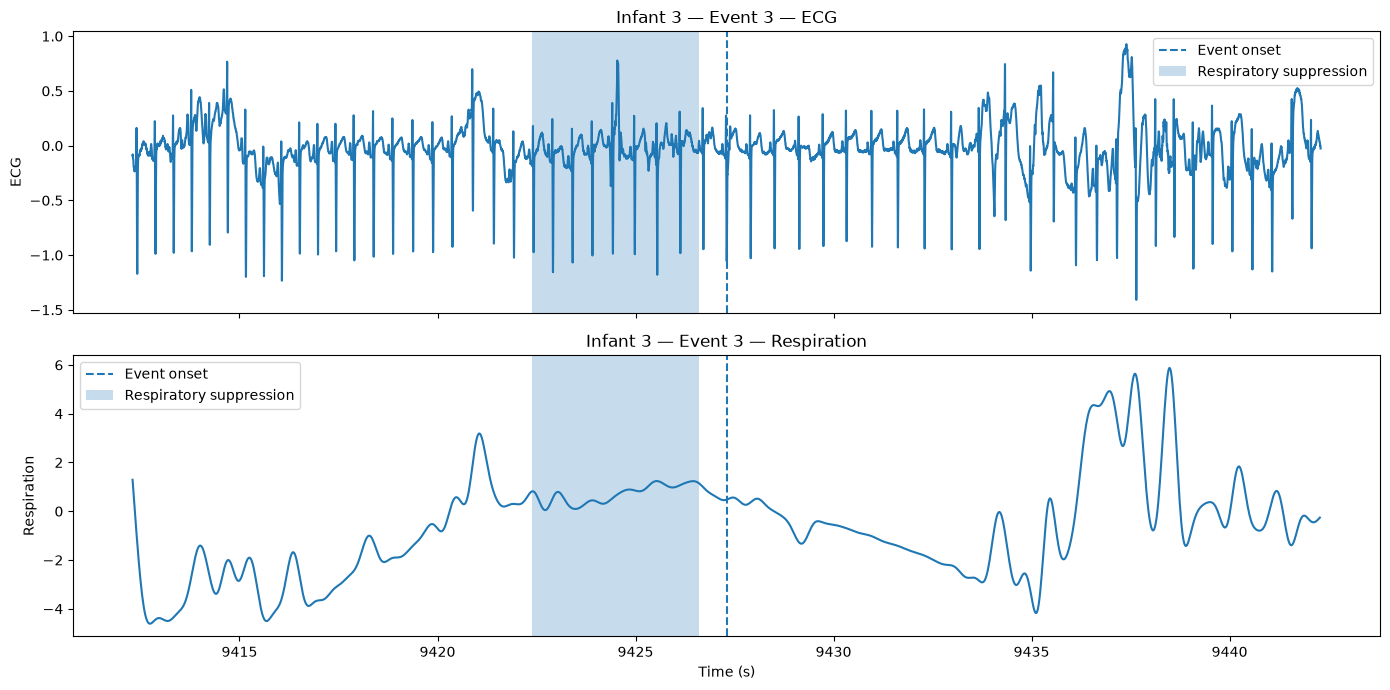


Infant 9 | Event 1
Event onset: 6900.050 s
Suppression: 6885.130–6890.230 s (5.10 s)


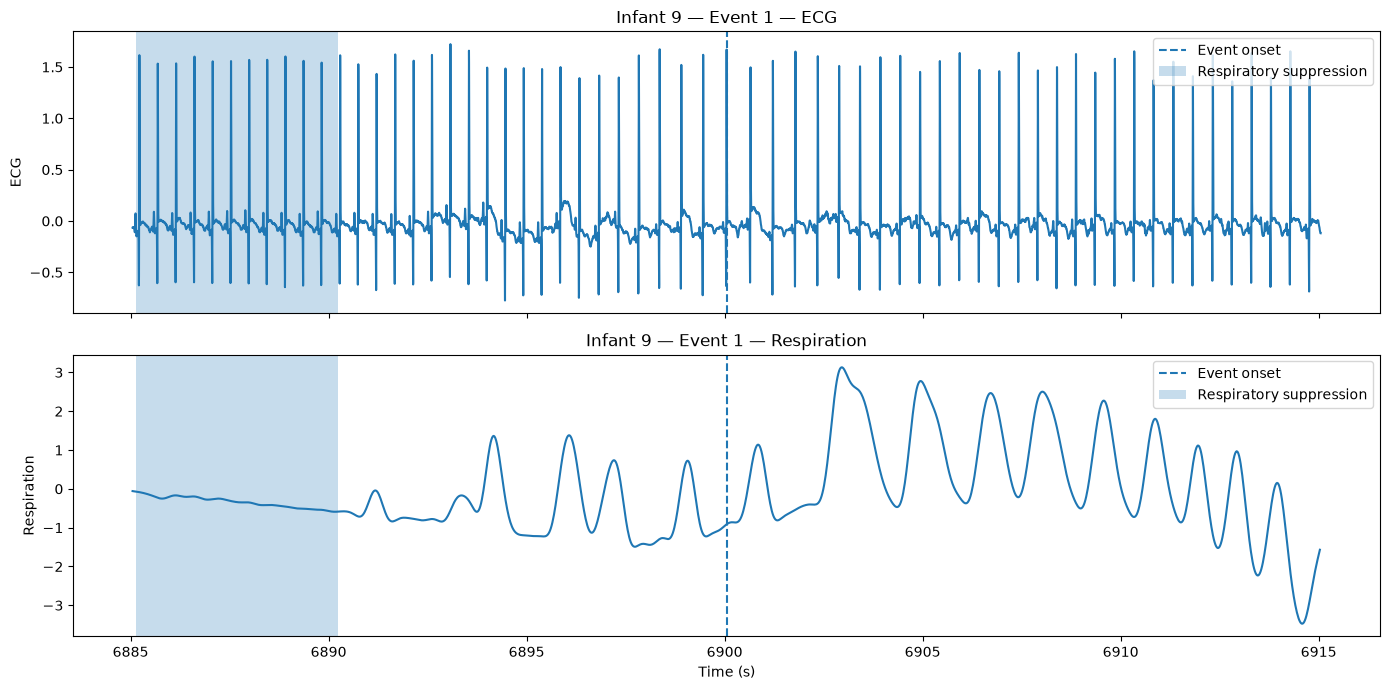


Infant 9 | Event 2
Event onset: 10072.600 s
Suppression: 10074.680–10077.820 s (3.14 s)


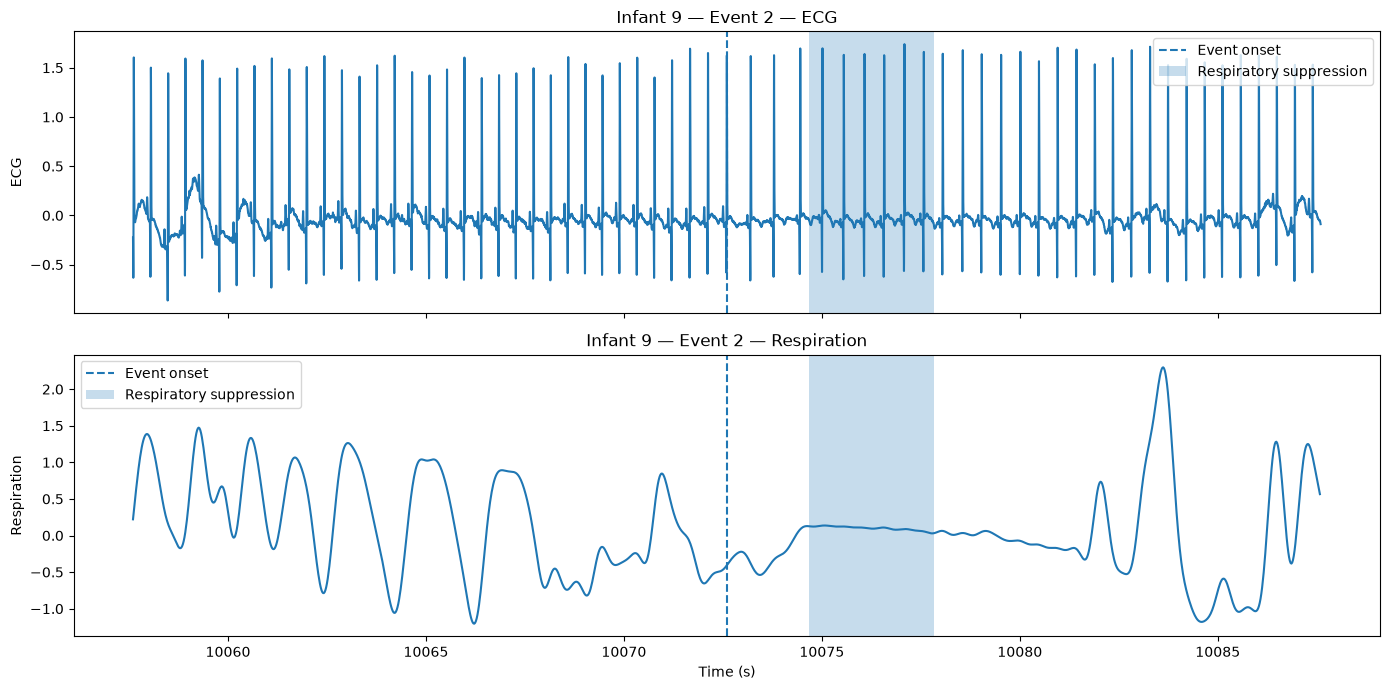


VISUAL INSPECTION COMPLETE


In [39]:
# Cell 42 — Visual inspection of respiratory-suppression candidates
# Validation/inspection only. Does not modify project data.

import numpy as np
import matplotlib.pyplot as plt
import wfdb


print("=" * 70)
print("VISUAL INSPECTION OF RESPIRATORY-SUPPRESSION CANDIDATES")
print("=" * 70)


for _, candidate in candidate_suppression_intervals_df.iterrows():

    infant = int(candidate["infant"])
    event_number = int(candidate["event_number"])
    event_time = float(candidate["event_time_s"])

    resp_start_s = float(candidate["resp_start_s"])
    resp_end_s = float(candidate["resp_end_s"])

    # Inspect a 30-second window around the candidate
    plot_start = event_time - 15.0
    plot_end = event_time + 15.0

    info = record_info_df[
        record_info_df["infant"] == infant
    ].iloc[0]

    ecg_fs = float(info["ecg_fs"])
    resp_fs = float(info["resp_fs"])

    ecg_start = int(round(plot_start * ecg_fs))
    ecg_end = int(round(plot_end * ecg_fs))

    resp_start = int(round(plot_start * resp_fs))
    resp_end = int(round(plot_end * resp_fs))

    ecg_record = wfdb.rdrecord(
        f"infant{infant}_ecg",
        pn_dir="picsdb/1.0.0",
        sampfrom=ecg_start,
        sampto=ecg_end
    )

    resp_record = wfdb.rdrecord(
        f"infant{infant}_resp",
        pn_dir="picsdb/1.0.0",
        sampfrom=resp_start,
        sampto=resp_end
    )

    ecg_signal = ecg_record.p_signal[:, 0]
    resp_signal = resp_record.p_signal[:, 0]

    filtered_resp = filter_respiration_signal_recovery(
        resp_signal,
        resp_fs
    )

    ecg_time = (
        np.arange(len(ecg_signal)) / ecg_fs
        + plot_start
    )

    resp_time = (
        np.arange(len(filtered_resp)) / resp_fs
        + plot_start
    )

    print()
    print("=" * 70)
    print(
        f"Infant {infant} | "
        f"Event {event_number}"
    )
    print(
        f"Event onset: {event_time:.3f} s"
    )
    print(
        f"Suppression: "
        f"{resp_start_s:.3f}–{resp_end_s:.3f} s "
        f"({resp_end_s - resp_start_s:.2f} s)"
    )

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(14, 7),
        sharex=True
    )

    # ECG
    axes[0].plot(
        ecg_time,
        ecg_signal
    )

    axes[0].axvline(
        event_time,
        linestyle="--",
        label="Event onset"
    )

    axes[0].axvspan(
        resp_start_s,
        resp_end_s,
        alpha=0.25,
        label="Respiratory suppression"
    )

    axes[0].set_ylabel("ECG")
    axes[0].set_title(
        f"Infant {infant} — Event {event_number} — ECG"
    )
    axes[0].legend()

    # Respiration
    axes[1].plot(
        resp_time,
        filtered_resp
    )

    axes[1].axvline(
        event_time,
        linestyle="--",
        label="Event onset"
    )

    axes[1].axvspan(
        resp_start_s,
        resp_end_s,
        alpha=0.25,
        label="Respiratory suppression"
    )

    axes[1].set_xlabel("Time (s)")
    axes[1].set_ylabel("Respiration")
    axes[1].set_title(
        f"Infant {infant} — Event {event_number} — Respiration"
    )
    axes[1].legend()

    plt.tight_layout()
    plt.show()


print()
print("=" * 70)
print("VISUAL INSPECTION COMPLETE")
print("=" * 70)

In [40]:
# Cell 43 — Freeze visually validated respiratory-suppression candidates
# Validation checkpoint only.
# These are NOT confirmed apnea events.

validated_suppression_candidates = candidate_suppression_intervals_df.copy()

validated_suppression_candidates = (
    validated_suppression_candidates
    .sort_values(
        ["infant", "event_number"]
    )
    .reset_index(drop=True)
)

print("=" * 70)
print("VALIDATED RESPIRATORY-SUPPRESSION CANDIDATES")
print("=" * 70)

print()
print("Number of visually validated candidates:",
      len(validated_suppression_candidates))

display(
    validated_suppression_candidates[
        [
            "infant",
            "event_number",
            "event_time_s",
            "resp_start_s",
            "resp_end_s",
            "resp_duration_s"
        ]
    ]
)

print()
print("=" * 70)
print("VALIDATION STATUS")
print("=" * 70)

print("Signal-level visual inspection: COMPLETE")
print("Candidates retained:", len(validated_suppression_candidates))
print("Clinical apnea confirmation: NOT CLAIMED")
print("Use in precursor labeling: READY FOR NEXT STEP")

VALIDATED RESPIRATORY-SUPPRESSION CANDIDATES

Number of visually validated candidates: 3


,infant,event_number,event_time_s,resp_start_s,resp_end_s,resp_duration_s
0,3,3,9427.30,9422.38,9426.60,4.22
1,9,1,6900.05,6885.13,6890.23,5.10
2,9,2,10072.60,10074.68,10077.82,3.14



VALIDATION STATUS
Signal-level visual inspection: COMPLETE
Candidates retained: 3
Clinical apnea confirmation: NOT CLAIMED
Use in precursor labeling: READY FOR NEXT STEP


In [41]:
# Cell 44 — Define precursor windows for validated suppression candidates
# Validation/development stage.
# The precursor window contains ONLY time before the detected event onset.

PRECURSOR_DURATION = 15.0

precursor_windows = []

for _, candidate in validated_suppression_candidates.iterrows():

    infant = int(candidate["infant"])
    event_number = int(candidate["event_number"])
    event_time = float(candidate["event_time_s"])

    precursor_start = event_time - PRECURSOR_DURATION
    precursor_end = event_time

    precursor_windows.append({
        "infant": infant,
        "event_number": event_number,
        "event_time_s": event_time,
        "precursor_start_s": precursor_start,
        "precursor_end_s": precursor_end,
        "precursor_duration_s": (
            precursor_end - precursor_start
        )
    })

precursor_windows_df = pd.DataFrame(
    precursor_windows
)

print("=" * 70)
print("PRECURSOR WINDOWS")
print("=" * 70)

print()
print(
    "Precursor duration:",
    PRECURSOR_DURATION,
    "seconds"
)

print(
    "Number of precursor windows:",
    len(precursor_windows_df)
)

print()

display(precursor_windows_df)

print()
print("=" * 70)
print("PRECURSOR WINDOW CHECK")
print("=" * 70)

print(
    "All windows end at event onset:",
    np.allclose(
        precursor_windows_df["precursor_end_s"],
        precursor_windows_df["event_time_s"]
    )
)

print(
    "All durations correct:",
    np.allclose(
        precursor_windows_df["precursor_duration_s"],
        PRECURSOR_DURATION
    )
)

print(
    "No precursor extends beyond event onset:",
    bool(
        (
            precursor_windows_df["precursor_end_s"]
            <= precursor_windows_df["event_time_s"]
        ).all()
    )
)

print()
print("=" * 70)
print("PRECURSOR WINDOWS READY")
print("=" * 70)

PRECURSOR WINDOWS

Precursor duration: 15.0 seconds
Number of precursor windows: 3



,infant,event_number,event_time_s,precursor_start_s,precursor_end_s,precursor_duration_s
0,3,3,9427.30,9412.30,9427.30,15.0
1,9,1,6900.05,6885.05,6900.05,15.0
2,9,2,10072.60,10057.60,10072.60,15.0



PRECURSOR WINDOW CHECK
All windows end at event onset: True
All durations correct: True
No precursor extends beyond event onset: True

PRECURSOR WINDOWS READY


In [ ]:
# Cell 45 — Load signals for validated 15-second precursor windows
# Development/validation stage.
# Uses infant-specific ECG and respiration sampling frequencies.

precursor_signal_records = []

for _, window in precursor_windows_df.iterrows():

    infant = int(window["infant"])
    event_number = int(window["event_number"])

    start_time = float(window["precursor_start_s"])
    end_time = float(window["precursor_end_s"])

    info = record_info_df[
        record_info_df["infant"] == infant
    ].iloc[0]

    ecg_fs = float(info["ecg_fs"])
    resp_fs = float(info["resp_fs"])

    ecg_start = int(round(start_time * ecg_fs))
    ecg_end = int(round(end_time * ecg_fs))

    resp_start = int(round(start_time * resp_fs))
    resp_end = int(round(end_time * resp_fs))

    ecg_record = wfdb.rdrecord(
        f"infant{infant}_ecg",
        pn_dir="picsdb/1.0.0",
        sampfrom=ecg_start,
        sampto=ecg_end
    )

    resp_record = wfdb.rdrecord(
        f"infant{infant}_resp",
        pn_dir="picsdb/1.0.0",
        sampfrom=resp_start,
        sampto=resp_end
    )

    ecg_signal = ecg_record.p_signal[:, 0]
    resp_signal = resp_record.p_signal[:, 0]

    precursor_signal_records.append({
        "infant": infant,
        "event_number": event_number,
        "event_time_s": float(window["event_time_s"]),
        "start_time_s": start_time,
        "end_time_s": end_time,
        "ecg_fs": ecg_fs,
        "resp_fs": resp_fs,
        "ecg_signal": ecg_signal,
        "resp_signal": resp_signal
    })

print("=" * 70)
print("PRECURSOR SIGNALS LOADED")
print("=" * 70)

print()
print("Number of windows:", len(precursor_signal_records))
print()

for record in precursor_signal_records:

    expected_ecg = int(
        round(
            (record["end_time_s"] - record["start_time_s"])
            * record["ecg_fs"]
        )
    )

    expected_resp = int(
        round(
            (record["end_time_s"] - record["start_time_s"])
            * record["resp_fs"]
        )
    )

    print(
        f"Infant {record['infant']} | "
        f"Event {record['event_number']} | "
        f"ECG: {len(record['ecg_signal'])} "
        f"(expected {expected_ecg}) | "
        f"Resp: {len(record['resp_signal'])} "
        f"(expected {expected_resp})"
    )

print()
print("=" * 70)
print("SIGNAL LOADING CHECK")
print("=" * 70)

print(
    "All ECG lengths correct:",
    all(
        len(r["ecg_signal"]) ==
        int(round(
            (r["end_time_s"] - r["start_time_s"])
            * r["ecg_fs"]
        ))
        for r in precursor_signal_records
    )
)

print(
    "All respiration lengths correct:",
    all(
        len(r["resp_signal"]) ==
        int(round(
            (r["end_time_s"] - r["start_time_s"])
            * r["resp_fs"]
        ))
        for r in precursor_signal_records
    )
)

print()
print("=" * 70)
print("PRECURSOR SIGNALS READY")    
print("=" * 70)

PRECURSOR SIGNALS LOADED

Number of windows: 3

Infant 3 | Event 3 | ECG: 7500 (expected 7500) | Resp: 750 (expected 750)
Infant 9 | Event 1 | ECG: 7500 (expected 7500) | Resp: 750 (expected 750)
Infant 9 | Event 2 | ECG: 7500 (expected 7500) | Resp: 750 (expected 750)

SIGNAL LOADING CHECK
All ECG lengths correct: True
All respiration lengths correct: True

PRECURSOR SIGNALS READY


In [43]:
# Cell 46 — Preprocess validated precursor signals
# Uses the established sampling-rate-aware SOS filters.

for record in precursor_signal_records:

    # ECG preprocessing
    record["ecg_filtered"] = sosfiltfilt(
        build_ecg_filter(record["ecg_fs"]),
        record["ecg_signal"]
    )

    # Respiration preprocessing
    record["resp_filtered"] = sosfiltfilt(
        build_resp_filter(record["resp_fs"]),
        record["resp_signal"]
    )

print("=" * 70)
print("PRECURSOR SIGNAL PREPROCESSING COMPLETE")
print("=" * 70)

for record in precursor_signal_records:

    print(
        f"Infant {record['infant']} | "
        f"Event {record['event_number']} | "
        f"ECG samples: {len(record['ecg_filtered'])} | "
        f"Resp samples: {len(record['resp_filtered'])} | "
        f"ECG finite: {np.isfinite(record['ecg_filtered']).all()} | "
        f"Resp finite: {np.isfinite(record['resp_filtered']).all()}"
    )

print()
print("=" * 70)
print("PREPROCESSING CHECK")
print("=" * 70)

print(
    "All ECG filtered signals finite:",
    all(
        np.isfinite(r["ecg_filtered"]).all()
        for r in precursor_signal_records
    )
)

print(
    "All respiration filtered signals finite:",
    all(
        np.isfinite(r["resp_filtered"]).all()
        for r in precursor_signal_records
    )
)

print()
print("=" * 70)
print("PREPROCESSED PRECURSOR SIGNALS READY")
print("=" * 70)

PRECURSOR SIGNAL PREPROCESSING COMPLETE
Infant 3 | Event 3 | ECG samples: 7500 | Resp samples: 750 | ECG finite: True | Resp finite: True
Infant 9 | Event 1 | ECG samples: 7500 | Resp samples: 750 | ECG finite: True | Resp finite: True
Infant 9 | Event 2 | ECG samples: 7500 | Resp samples: 750 | ECG finite: True | Resp finite: True

PREPROCESSING CHECK
All ECG filtered signals finite: True
All respiration filtered signals finite: True

PREPROCESSED PRECURSOR SIGNALS READY


In [44]:
# Cell 47 — Extract physiological features from validated precursor windows

def extract_precursor_features(record):
    
    ecg = record["ecg_filtered"]
    resp = record["resp_filtered"]
    ecg_fs = record["ecg_fs"]
    resp_fs = record["resp_fs"]

    features = {}

    # ------------------------------------------------------------
    # ECG signal-level features
    # ------------------------------------------------------------
    features["ecg_mean"] = np.mean(ecg)
    features["ecg_std"] = np.std(ecg)
    features["ecg_rms"] = np.sqrt(np.mean(ecg ** 2))

    # ------------------------------------------------------------
    # R-peak detection
    # Same detector established earlier
    # ------------------------------------------------------------
    r_peaks, _ = detect_r_peaks(ecg, ecg_fs)

    features["r_peak_count"] = len(r_peaks)

    # ------------------------------------------------------------
    # RR / HR features
    # ------------------------------------------------------------
    if len(r_peaks) > 1:

        r_peak_times = r_peaks / ecg_fs

        rr = np.diff(r_peak_times)
        hr = 60.0 / rr

        features["mean_rr"] = np.mean(rr)
        features["std_rr"] = np.std(rr)

        features["mean_hr"] = np.mean(hr)
        features["min_hr"] = np.min(hr)
        features["max_hr"] = np.max(hr)
        features["std_hr"] = np.std(hr)

        # SDNN
        features["sdnn"] = np.std(rr, ddof=1) if len(rr) > 1 else 0.0

        # RMSSD
        if len(rr) > 1:
            features["rmssd"] = np.sqrt(
                np.mean(np.diff(rr) ** 2)
            )
        else:
            features["rmssd"] = 0.0

    else:

        features["mean_rr"] = np.nan
        features["std_rr"] = np.nan
        features["mean_hr"] = np.nan
        features["min_hr"] = np.nan
        features["max_hr"] = np.nan
        features["std_hr"] = np.nan
        features["sdnn"] = np.nan
        features["rmssd"] = np.nan

    # ------------------------------------------------------------
    # Respiration signal-level features
    # ------------------------------------------------------------
    features["resp_mean"] = np.mean(resp)
    features["resp_std"] = np.std(resp)
    features["resp_rms"] = np.sqrt(np.mean(resp ** 2))

    # ------------------------------------------------------------
    # Respiration peak detection
    # ------------------------------------------------------------
    resp_peaks, _ = find_peaks(
        resp,
        distance=max(1, int(0.8 * resp_fs)),
        prominence=0.1 * np.std(resp)
    )

    features["resp_peak_count"] = len(resp_peaks)

    # ------------------------------------------------------------
    # Respiration interval / rate features
    # ------------------------------------------------------------
    if len(resp_peaks) > 1:

        resp_peak_times = resp_peaks / resp_fs
        resp_intervals = np.diff(resp_peak_times)

        resp_rates = 60.0 / resp_intervals

        features["mean_resp_interval"] = np.mean(resp_intervals)
        features["std_resp_interval"] = np.std(resp_intervals)

        features["mean_resp_rate"] = np.mean(resp_rates)
        features["std_resp_rate"] = np.std(resp_rates)

    else:

        features["mean_resp_interval"] = np.nan
        features["std_resp_interval"] = np.nan
        features["mean_resp_rate"] = np.nan
        features["std_resp_rate"] = np.nan

    return features


precursor_feature_rows = []

for record in precursor_signal_records:

    features = extract_precursor_features(record)

    row = {
        "infant": record["infant"],
        "event_number": record["event_number"],
        "event_time_s": record["event_time_s"],
        "precursor_start_s": record["start_time_s"],
        "precursor_end_s": record["end_time_s"],
        **features
    }

    precursor_feature_rows.append(row)


precursor_features_df = pd.DataFrame(
    precursor_feature_rows
)

print("=" * 70)
print("PRECURSOR FEATURE EXTRACTION COMPLETE")
print("=" * 70)

print()
print("Feature dataset shape:", precursor_features_df.shape)

print()
print("Columns:")
for i, column in enumerate(precursor_features_df.columns, start=1):
    print(f"{i:2d}: {column}")

print()
print("=" * 70)
print("FEATURE VALUES")
print("=" * 70)

display(precursor_features_df)

print()
print("=" * 70)
print("FEATURE QC")
print("=" * 70)

numeric_features = precursor_features_df.select_dtypes(
    include=[np.number]
)

print(
    "NaN values present:",
    numeric_features.isna().any().any()
)

print(
    "Infinite values present:",
    np.isinf(numeric_features.to_numpy()).any()
)

PRECURSOR FEATURE EXTRACTION COMPLETE

Feature dataset shape: (3, 25)

Columns:
 1: infant
 2: event_number
 3: event_time_s
 4: precursor_start_s
 5: precursor_end_s
 6: ecg_mean
 7: ecg_std
 8: ecg_rms
 9: r_peak_count
10: mean_rr
11: std_rr
12: mean_hr
13: min_hr
14: max_hr
15: std_hr
16: sdnn
17: rmssd
18: resp_mean
19: resp_std
20: resp_rms
21: resp_peak_count
22: mean_resp_interval
23: std_resp_interval
24: mean_resp_rate
25: std_resp_rate

FEATURE VALUES


,infant,event_number,event_time_s,precursor_start_s,precursor_end_s,ecg_mean,ecg_std,ecg_rms,r_peak_count,mean_rr,...,sdnn,rmssd,resp_mean,resp_std,resp_rms,resp_peak_count,mean_resp_interval,std_resp_interval,mean_resp_rate,std_resp_rate
0,3,3,9427.30,9412.30,9427.30,-0.000628,0.212808,0.212809,29,0.531643,...,0.120608,0.153095,-1.268254,2.156268,2.501591,9,1.557500,0.503134,42.587954,13.074591
1,9,1,6900.05,6885.05,6900.05,-0.001226,0.272242,0.272245,31,0.474533,...,0.026113,0.009006,-0.035287,0.585318,0.586381,7,2.153333,1.374902,38.482715,20.193295
2,9,2,10072.60,10057.60,10072.60,0.003049,0.291480,0.291496,34,0.439515,...,0.005386,0.004047,0.157290,0.656206,0.674794,10,1.444444,0.305327,43.107402,7.584589



FEATURE QC
NaN values present: False
Infinite values present: False


In [45]:
# Cell 48 — Validate precursor feature matrix

print("=" * 70)
print("PRECURSOR FEATURE MATRIX QC")
print("=" * 70)

# Feature columns only
feature_columns = [
    "ecg_mean",
    "ecg_std",
    "ecg_rms",
    "r_peak_count",
    "mean_rr",
    "std_rr",
    "mean_hr",
    "min_hr",
    "max_hr",
    "std_hr",
    "sdnn",
    "rmssd",
    "resp_mean",
    "resp_std",
    "resp_rms",
    "resp_peak_count",
    "mean_resp_interval",
    "std_resp_interval",
    "mean_resp_rate",
    "std_resp_rate"
]

X_precursor = precursor_features_df[feature_columns].copy()

print()
print("Feature matrix shape:", X_precursor.shape)
print("Expected rows:", len(precursor_signal_records))
print("Expected features:", len(feature_columns))

print()
print("NaN values:", X_precursor.isna().sum().sum())
print(
    "Infinite values:",
    np.isinf(X_precursor.to_numpy(dtype=float)).sum()
)

print()
print("=" * 70)
print("FEATURE-BY-FEATURE QC")
print("=" * 70)

qc_table = pd.DataFrame({
    "feature": feature_columns,
    "missing": X_precursor.isna().sum().values,
    "infinite": [
        np.isinf(X_precursor[col].to_numpy(dtype=float)).sum()
        for col in feature_columns
    ]
})

display(qc_table)

print()
print("=" * 70)
print("OVERALL STATUS")
print("=" * 70)

print(
    "Correct number of rows:",
    X_precursor.shape[0] == 3
)

print(
    "Correct number of features:",
    X_precursor.shape[1] == 20
)

print(
    "No NaN values:",
    not X_precursor.isna().any().any()
)

print(
    "No infinite values:",
    not np.isinf(X_precursor.to_numpy(dtype=float)).any()
)

print()
print("=" * 70)
print("PRECURSOR FEATURE MATRIX READY")
print("=" * 70)

PRECURSOR FEATURE MATRIX QC

Feature matrix shape: (3, 20)
Expected rows: 3
Expected features: 20

NaN values: 0
Infinite values: 0

FEATURE-BY-FEATURE QC


,feature,missing,infinite
0,ecg_mean,0,0
1,ecg_std,0,0
2,ecg_rms,0,0
3,r_peak_count,0,0
4,mean_rr,0,0
5,std_rr,0,0
6,mean_hr,0,0
7,min_hr,0,0
8,max_hr,0,0
9,std_hr,0,0



OVERALL STATUS
Correct number of rows: True
Correct number of features: True
No NaN values: True
No infinite values: True

PRECURSOR FEATURE MATRIX READY


In [46]:
# Cell 49 — Select temporally safe control windows
# Development dataset construction.
#
# Controls are 15-second windows selected from the same infants,
# away from all known PICS bradycardia event onsets.

CONTROL_DURATION = 15.0
CONTROL_MIN_DISTANCE = 60.0

# Use the same infants represented in the validated precursor set
control_infants = sorted(
    set(int(x["infant"]) for x in precursor_signal_records)
)

# All known event times for those infants
event_times_by_infant = {}

for infant in control_infants:
    event_times_by_infant[infant] = events_df[
        events_df["infant"] == infant
    ]["event_time_s"].to_numpy(dtype=float)

# Record duration information
record_duration_by_infant = {}

for infant in control_infants:
    info = record_info_df[
        record_info_df["infant"] == infant
    ].iloc[0]

    record_duration_by_infant[infant] = float(
        info["ecg_samples"] / info["ecg_fs"]
    )

# Candidate control centers distributed through the recording
control_candidates = []

for infant in control_infants:

    duration = record_duration_by_infant[infant]
    event_times = event_times_by_infant[infant]

    # Avoid the very beginning/end because a complete 15-second
    # control window must fit inside the recording.
    start_min = CONTROL_DURATION / 2
    start_max = duration - CONTROL_DURATION / 2

    candidate_centers = np.linspace(
        start_min,
        start_max,
        1000
    )

    for center in candidate_centers:

        # Minimum distance from every known event onset
        if len(event_times) > 0:
            min_distance = np.min(
                np.abs(event_times - center)
            )
        else:
            min_distance = np.inf

        if min_distance >= CONTROL_MIN_DISTANCE:

            control_candidates.append({
                "infant": infant,
                "center_time_s": float(center),
                "control_start_s": float(
                    center - CONTROL_DURATION / 2
                ),
                "control_end_s": float(
                    center + CONTROL_DURATION / 2
                ),
                "min_distance_from_event_s": float(
                    min_distance
                )
            })

# Select one control for each validated precursor infant/event.
# Choose candidates spread through the recording.

selected_controls = []

for record in precursor_signal_records:

    infant = int(record["infant"])

    candidates = [
        candidate
        for candidate in control_candidates
        if candidate["infant"] == infant
    ]

    if len(candidates) == 0:
        raise RuntimeError(
            f"No safe control candidate found for infant {infant}"
        )

    # Prefer a candidate well separated from previously selected
    # controls from the same infant.
    selected = None

    for candidate in candidates:

        too_close = False

        for previous in selected_controls:

            if previous["infant"] == infant:

                if abs(
                    candidate["center_time_s"]
                    - previous["center_time_s"]
                ) < CONTROL_MIN_DISTANCE:
                    too_close = True
                    break

        if not too_close:
            selected = candidate
            break

    if selected is None:
        raise RuntimeError(
            f"Could not select a sufficiently separated "
            f"control for infant {infant}"
        )

    selected_controls.append(selected)

control_windows_df = pd.DataFrame(selected_controls)

print("=" * 70)
print("CONTROL WINDOWS")
print("=" * 70)

print()
print("Number of control windows:", len(control_windows_df))

display(control_windows_df)

print()
print("=" * 70)
print("CONTROL WINDOW SAFETY CHECK")
print("=" * 70)

print(
    "All controls are at least",
    CONTROL_MIN_DISTANCE,
    "seconds from known event onsets:",
    (
        control_windows_df["min_distance_from_event_s"]
        >= CONTROL_MIN_DISTANCE
    ).all()
)

print(
    "All control durations correct:",
    np.allclose(
        control_windows_df["control_end_s"]
        - control_windows_df["control_start_s"],
        CONTROL_DURATION
    )
)

print()
print("=" * 70)
print("CONTROL WINDOWS READY")
print("=" * 70)

CONTROL WINDOWS

Number of control windows: 3


,infant,center_time_s,control_start_s,control_end_s,min_distance_from_event_s
0,3,165.011740,157.511740,172.511740,155.393740
1,9,7.500000,0.000000,15.000000,6892.550000
2,9,260.876553,253.376553,268.376553,6639.173447



CONTROL WINDOW SAFETY CHECK
All controls are at least 60.0 seconds from known event onsets: True
All control durations correct: True

CONTROL WINDOWS READY


In [47]:
# Cell 49 — Revised temporally safe control-window selection
# Avoid recording boundaries to prevent preprocessing edge effects.

CONTROL_DURATION = 15.0
CONTROL_MIN_DISTANCE = 60.0
CONTROL_EDGE_MARGIN = 30.0

control_infants = sorted(
    set(int(x["infant"]) for x in precursor_signal_records)
)

event_times_by_infant = {}

for infant in control_infants:
    event_times_by_infant[infant] = events_df[
        events_df["infant"] == infant
    ]["event_time_s"].to_numpy(dtype=float)

record_duration_by_infant = {}

for infant in control_infants:
    info = record_info_df[
        record_info_df["infant"] == infant
    ].iloc[0]

    record_duration_by_infant[infant] = float(
        info["ecg_samples"] / info["ecg_fs"]
    )

control_candidates = []

for infant in control_infants:

    duration = record_duration_by_infant[infant]
    event_times = event_times_by_infant[infant]

    # Require the COMPLETE control window to remain
    # at least 30 seconds away from either recording boundary.
    start_min = CONTROL_EDGE_MARGIN + CONTROL_DURATION / 2
    start_max = (
        duration
        - CONTROL_EDGE_MARGIN
        - CONTROL_DURATION / 2
    )

    candidate_centers = np.linspace(
        start_min,
        start_max,
        1000
    )

    for center in candidate_centers:

        if len(event_times) > 0:
            min_distance = np.min(
                np.abs(event_times - center)
            )
        else:
            min_distance = np.inf

        if min_distance >= CONTROL_MIN_DISTANCE:

            control_candidates.append({
                "infant": infant,
                "center_time_s": float(center),
                "control_start_s": float(
                    center - CONTROL_DURATION / 2
                ),
                "control_end_s": float(
                    center + CONTROL_DURATION / 2
                ),
                "min_distance_from_event_s": float(
                    min_distance
                )
            })

selected_controls = []

for record in precursor_signal_records:

    infant = int(record["infant"])

    candidates = [
        candidate
        for candidate in control_candidates
        if candidate["infant"] == infant
    ]

    if len(candidates) == 0:
        raise RuntimeError(
            f"No safe control candidate found for infant {infant}"
        )

    selected = None

    for candidate in candidates:

        too_close = False

        for previous in selected_controls:

            if previous["infant"] == infant:

                if abs(
                    candidate["center_time_s"]
                    - previous["center_time_s"]
                ) < CONTROL_MIN_DISTANCE:
                    too_close = True
                    break

        if not too_close:
            selected = candidate
            break

    if selected is None:
        raise RuntimeError(
            f"Could not select a sufficiently separated "
            f"control for infant {infant}"
        )

    selected_controls.append(selected)

control_windows_df = pd.DataFrame(selected_controls)

print("=" * 70)
print("REVISED CONTROL WINDOWS")
print("=" * 70)

print()
print("Number of control windows:", len(control_windows_df))

display(control_windows_df)

print()
print("=" * 70)
print("CONTROL WINDOW SAFETY CHECK")
print("=" * 70)

print(
    "All controls are at least",
    CONTROL_MIN_DISTANCE,
    "seconds from known event onsets:",
    (
        control_windows_df["min_distance_from_event_s"]
        >= CONTROL_MIN_DISTANCE
    ).all()
)

print(
    "All controls have the required edge margin:",
    (
        (control_windows_df["control_start_s"] >= CONTROL_EDGE_MARGIN)
        &
        (
            control_windows_df["control_end_s"]
            <= (
                control_windows_df["infant"].map(
                    record_duration_by_infant
                )
                - CONTROL_EDGE_MARGIN
            )
        )
    ).all()
)

print(
    "All control durations correct:",
    np.allclose(
        control_windows_df["control_end_s"]
        - control_windows_df["control_start_s"],
        CONTROL_DURATION
    )
)

print()
print("=" * 70)
print("REVISED CONTROL WINDOWS READY")
print("=" * 70)

REVISED CONTROL WINDOWS

Number of control windows: 3


,infant,center_time_s,control_start_s,control_end_s,min_distance_from_event_s
0,3,194.951680,187.451680,202.451680,185.333680
1,9,37.500000,30.000000,45.000000,6862.550000
2,9,290.816492,283.316492,298.316492,6609.233508



CONTROL WINDOW SAFETY CHECK
All controls are at least 60.0 seconds from known event onsets: True
All controls have the required edge margin: True
All control durations correct: True

REVISED CONTROL WINDOWS READY


In [48]:
# Cell 50 — Load temporally safe control signals

control_signal_records = []

for _, control in control_windows_df.iterrows():

    infant = int(control["infant"])
    center_time = float(control["center_time_s"])
    control_start = float(control["control_start_s"])
    control_end = float(control["control_end_s"])

    info = record_info_df[
        record_info_df["infant"] == infant
    ].iloc[0]

    ecg_fs = float(info["ecg_fs"])
    resp_fs = float(info["resp_fs"])

    ecg_start = int(round(control_start * ecg_fs))
    ecg_end = int(round(control_end * ecg_fs))

    resp_start = int(round(control_start * resp_fs))
    resp_end = int(round(control_end * resp_fs))

    ecg_record = wfdb.rdrecord(
        f"infant{infant}_ecg",
        pn_dir="picsdb/1.0.0",
        sampfrom=ecg_start,
        sampto=ecg_end
    )

    resp_record = wfdb.rdrecord(
        f"infant{infant}_resp",
        pn_dir="picsdb/1.0.0",
        sampfrom=resp_start,
        sampto=resp_end
    )

    ecg_signal = ecg_record.p_signal[:, 0]
    resp_signal = resp_record.p_signal[:, 0]

    control_signal_records.append({
        "infant": infant,
        "center_time_s": center_time,
        "control_start_s": control_start,
        "control_end_s": control_end,
        "ecg_fs": ecg_fs,
        "resp_fs": resp_fs,
        "ecg_signal": ecg_signal,
        "resp_signal": resp_signal
    })

    print(
        f"Infant {infant} | "
        f"Control {control_start:.2f}–{control_end:.2f} s | "
        f"ECG: {len(ecg_signal)} | "
        f"Resp: {len(resp_signal)}"
    )

print()
print("=" * 70)
print("CONTROL SIGNAL LOADING CHECK")
print("=" * 70)

expected_ecg_lengths = [
    int(round(CONTROL_DURATION * record["ecg_fs"]))
    for record in control_signal_records
]

expected_resp_lengths = [
    int(round(CONTROL_DURATION * record["resp_fs"]))
    for record in control_signal_records
]

actual_ecg_lengths = [
    len(record["ecg_signal"])
    for record in control_signal_records
]

actual_resp_lengths = [
    len(record["resp_signal"])
    for record in control_signal_records
]

print(
    "All ECG lengths correct:",
    actual_ecg_lengths == expected_ecg_lengths
)

print(
    "All respiration lengths correct:",
    actual_resp_lengths == expected_resp_lengths
)

print()
print("=" * 70)
print("CONTROL SIGNALS READY")
print("=" * 70)

Infant 3 | Control 187.45–202.45 s | ECG: 7500 | Resp: 750
Infant 9 | Control 30.00–45.00 s | ECG: 7500 | Resp: 750
Infant 9 | Control 283.32–298.32 s | ECG: 7500 | Resp: 750

CONTROL SIGNAL LOADING CHECK
All ECG lengths correct: True
All respiration lengths correct: True

CONTROL SIGNALS READY


In [50]:
# Cell 51 — Preprocess control signals
# Uses the existing sampling-aware SOS ECG filter
# and the validated respiration preprocessing.

preprocessed_control_records = []

for record in control_signal_records:

    infant = int(record["infant"])

    ecg_signal = np.asarray(
        record["ecg_signal"],
        dtype=float
    )

    resp_signal = np.asarray(
        record["resp_signal"],
        dtype=float
    )

    ecg_fs = float(record["ecg_fs"])
    resp_fs = float(record["resp_fs"])

    # ECG preprocessing using the existing SOS filter
    ecg_sos = build_ecg_filter(ecg_fs)

    ecg_filtered = sosfiltfilt(
        ecg_sos,
        ecg_signal
    )

    # Respiration preprocessing using the existing
    # validated respiration filter function
    resp_filtered = filter_respiration_signal(
        resp_signal,
        resp_fs
    )

    preprocessed_control_records.append({
        "infant": infant,
        "center_time_s": record["center_time_s"],
        "control_start_s": record["control_start_s"],
        "control_end_s": record["control_end_s"],
        "ecg_fs": ecg_fs,
        "resp_fs": resp_fs,
        "ecg_filtered": ecg_filtered,
        "resp_filtered": resp_filtered
    })

    print(
        f"Infant {infant} | "
        f"Control {record['control_start_s']:.2f}–"
        f"{record['control_end_s']:.2f} s | "
        f"ECG samples: {len(ecg_filtered)} | "
        f"Resp samples: {len(resp_filtered)}"
    )

print()
print("=" * 70)
print("CONTROL SIGNAL PREPROCESSING COMPLETE")
print("=" * 70)

ecg_finite = all(
    np.isfinite(record["ecg_filtered"]).all()
    for record in preprocessed_control_records
)

resp_finite = all(
    np.isfinite(record["resp_filtered"]).all()
    for record in preprocessed_control_records
)

print("All ECG filtered signals finite:", ecg_finite)
print("All respiration filtered signals finite:", resp_finite)

print()
print("=" * 70)
print("PREPROCESSED CONTROL SIGNALS READY")
print("=" * 70)

Infant 3 | Control 187.45–202.45 s | ECG samples: 7500 | Resp samples: 750
Infant 9 | Control 30.00–45.00 s | ECG samples: 7500 | Resp samples: 750
Infant 9 | Control 283.32–298.32 s | ECG samples: 7500 | Resp samples: 750

CONTROL SIGNAL PREPROCESSING COMPLETE
All ECG filtered signals finite: True
All respiration filtered signals finite: True

PREPROCESSED CONTROL SIGNALS READY


In [51]:
# Cell 52 — Extract physiological features from control windows

control_feature_records = []

for record in preprocessed_control_records:

    infant = int(record["infant"])

    ecg = np.asarray(
        record["ecg_filtered"],
        dtype=float
    )

    resp = np.asarray(
        record["resp_filtered"],
        dtype=float
    )

    ecg_fs = float(record["ecg_fs"])
    resp_fs = float(record["resp_fs"])

    # --------------------------------------------------
    # ECG signal features
    # --------------------------------------------------

    ecg_mean = np.mean(ecg)
    ecg_std = np.std(ecg)
    ecg_rms = np.sqrt(np.mean(ecg ** 2))

    # R-peak detection
    r_peaks, _ = detect_r_peaks(
        ecg,
        ecg_fs
    )

    r_peak_times = r_peaks / ecg_fs

    # --------------------------------------------------
    # Heart-rate / RR features
    # --------------------------------------------------

    if len(r_peak_times) > 1:

        rr = np.diff(r_peak_times)
        hr = 60.0 / rr

        mean_rr = np.mean(rr)
        std_rr = np.std(rr)

        mean_hr = np.mean(hr)
        min_hr = np.min(hr)
        max_hr = np.max(hr)
        std_hr = np.std(hr)

        sdnn = np.std(rr)

        if len(rr) > 1:
            rmssd = np.sqrt(
                np.mean(
                    np.diff(rr) ** 2
                )
            )
        else:
            rmssd = 0.0

    else:

        mean_rr = 0.0
        std_rr = 0.0
        mean_hr = 0.0
        min_hr = 0.0
        max_hr = 0.0
        std_hr = 0.0
        sdnn = 0.0
        rmssd = 0.0

    # --------------------------------------------------
    # Respiration signal features
    # --------------------------------------------------

    resp_mean = np.mean(resp)
    resp_std = np.std(resp)
    resp_rms = np.sqrt(np.mean(resp ** 2))

    # Respiration peak detection
    resp_peaks, _ = find_peaks(
        resp,
        distance=max(1, int(0.8 * resp_fs)),
        prominence=0.1 * np.std(resp)
    )

    resp_peak_times = resp_peaks / resp_fs

    if len(resp_peak_times) > 1:

        resp_intervals = np.diff(
            resp_peak_times
        )

        mean_resp_interval = np.mean(
            resp_intervals
        )

        std_resp_interval = np.std(
            resp_intervals
        )

        mean_resp_rate = (
            60.0 / mean_resp_interval
            if mean_resp_interval > 0
            else 0.0
        )

        std_resp_rate = (
            np.std(
                60.0 / resp_intervals
            )
            if len(resp_intervals) > 0
            else 0.0
        )

    else:

        mean_resp_interval = 0.0
        std_resp_interval = 0.0
        mean_resp_rate = 0.0
        std_resp_rate = 0.0

    # --------------------------------------------------
    # Store 20 physiological features
    # --------------------------------------------------

    control_feature_records.append({
        "infant": infant,
        "center_time_s": record["center_time_s"],
        "control_start_s": record["control_start_s"],
        "control_end_s": record["control_end_s"],

        "ecg_mean": ecg_mean,
        "ecg_std": ecg_std,
        "ecg_rms": ecg_rms,

        "r_peak_count": len(r_peaks),
        "mean_rr": mean_rr,
        "std_rr": std_rr,
        "mean_hr": mean_hr,
        "min_hr": min_hr,
        "max_hr": max_hr,
        "std_hr": std_hr,
        "sdnn": sdnn,
        "rmssd": rmssd,

        "resp_mean": resp_mean,
        "resp_std": resp_std,
        "resp_rms": resp_rms,
        "resp_peak_count": len(resp_peaks),
        "mean_resp_interval": mean_resp_interval,
        "std_resp_interval": std_resp_interval,
        "mean_resp_rate": mean_resp_rate,
        "std_resp_rate": std_resp_rate
    })


control_features_df = pd.DataFrame(
    control_feature_records
)

print("=" * 70)
print("CONTROL FEATURE EXTRACTION COMPLETE")
print("=" * 70)

print()
print("Control feature dataset shape:",
      control_features_df.shape)

print()
print("FEATURE VALUES")
print("=" * 70)

display(control_features_df)

print()
print("=" * 70)
print("CONTROL FEATURE MATRIX READY")
print("=" * 70)

CONTROL FEATURE EXTRACTION COMPLETE

Control feature dataset shape: (3, 24)

FEATURE VALUES


,infant,center_time_s,control_start_s,control_end_s,ecg_mean,ecg_std,ecg_rms,r_peak_count,mean_rr,std_rr,...,sdnn,rmssd,resp_mean,resp_std,resp_rms,resp_peak_count,mean_resp_interval,std_resp_interval,mean_resp_rate,std_resp_rate
0,3,194.951680,187.451680,202.451680,0.006075,0.186216,0.186315,28,0.544296,0.107718,...,0.107718,0.159847,-0.003595,0.008366,0.009106,9,1.557500,0.573275,38.523274,15.265888
1,9,37.500000,30.000000,45.000000,-0.001652,0.214157,0.214164,34,0.441212,0.025607,...,0.025607,0.004848,-0.000268,0.000955,0.000992,13,1.153333,0.307607,52.023121,11.208738
2,9,290.816492,283.316492,298.316492,-0.000007,0.219804,0.219804,33,0.448250,0.006942,...,0.006942,0.004670,0.001337,0.004955,0.005133,9,1.682500,0.917248,35.661218,17.100789



CONTROL FEATURE MATRIX READY


In [52]:
# Cell 53 — Validate control feature matrix

CONTROL_FEATURE_COLUMNS = [
    "ecg_mean",
    "ecg_std",
    "ecg_rms",
    "r_peak_count",
    "mean_rr",
    "std_rr",
    "mean_hr",
    "min_hr",
    "max_hr",
    "std_hr",
    "sdnn",
    "rmssd",
    "resp_mean",
    "resp_std",
    "resp_rms",
    "resp_peak_count",
    "mean_resp_interval",
    "std_resp_interval",
    "mean_resp_rate",
    "std_resp_rate"
]

print("=" * 70)
print("CONTROL FEATURE MATRIX QC")
print("=" * 70)

X_control = control_features_df[
    CONTROL_FEATURE_COLUMNS
].to_numpy(dtype=float)

print()
print("Feature matrix shape:", X_control.shape)
print("Expected rows:", len(control_signal_records))
print("Expected features:", len(CONTROL_FEATURE_COLUMNS))

print()
print("NaN values:", np.isnan(X_control).sum())
print("Infinite values:", np.isinf(X_control).sum())

print()
print("=" * 70)
print("FEATURE-BY-FEATURE QC")
print("=" * 70)

control_feature_qc = pd.DataFrame({
    "feature": CONTROL_FEATURE_COLUMNS,
    "missing": [
        control_features_df[col].isna().sum()
        for col in CONTROL_FEATURE_COLUMNS
    ],
    "infinite": [
        np.isinf(
            control_features_df[col].to_numpy(dtype=float)
        ).sum()
        for col in CONTROL_FEATURE_COLUMNS
    ]
})

display(control_feature_qc)

print()
print("=" * 70)
print("OVERALL STATUS")
print("=" * 70)

correct_rows = (
    X_control.shape[0] == len(control_signal_records)
)

correct_features = (
    X_control.shape[1] == len(CONTROL_FEATURE_COLUMNS)
)

no_nan = not np.isnan(X_control).any()
no_inf = not np.isinf(X_control).any()

print("Correct number of rows:", correct_rows)
print("Correct number of features:", correct_features)
print("No NaN values:", no_nan)
print("No infinite values:", no_inf)

print()
print("=" * 70)

if correct_rows and correct_features and no_nan and no_inf:
    print("CONTROL FEATURE MATRIX READY")
else:
    print("CONTROL FEATURE MATRIX REQUIRES REVIEW")

print("=" * 70)

CONTROL FEATURE MATRIX QC

Feature matrix shape: (3, 20)
Expected rows: 3
Expected features: 20

NaN values: 0
Infinite values: 0

FEATURE-BY-FEATURE QC


,feature,missing,infinite
0,ecg_mean,0,0
1,ecg_std,0,0
2,ecg_rms,0,0
3,r_peak_count,0,0
4,mean_rr,0,0
5,std_rr,0,0
6,mean_hr,0,0
7,min_hr,0,0
8,max_hr,0,0
9,std_hr,0,0



OVERALL STATUS
Correct number of rows: True
Correct number of features: True
No NaN values: True
No infinite values: True

CONTROL FEATURE MATRIX READY


In [53]:
# Cell 54 — Combine precursor and control feature datasets

print("=" * 70)
print("COMBINING PRECURSOR AND CONTROL FEATURES")
print("=" * 70)

# Copy precursor features
precursor_df = precursor_features_df.copy()

# Copy control features
control_df = control_features_df.copy()

# Add risk labels
precursor_df["risk_label"] = 1
control_df["risk_label"] = 0

# Keep only common metadata + physiological features + label
COMBINED_COLUMNS = [
    "infant",
    "event_number",
    "event_time_s",
    "precursor_start_s",
    "precursor_end_s",
] + CONTROL_FEATURE_COLUMNS + ["risk_label"]

# Control windows do not have event metadata.
# Add compatible metadata fields.
control_df["event_number"] = np.nan
control_df["event_time_s"] = np.nan
control_df["precursor_start_s"] = np.nan
control_df["precursor_end_s"] = np.nan

# Reorder columns
precursor_df = precursor_df[COMBINED_COLUMNS]
control_df = control_df[COMBINED_COLUMNS]

# Combine
development_feature_dataset = pd.concat(
    [precursor_df, control_df],
    ignore_index=True
)

print()
print("Precursor samples:", len(precursor_df))
print("Control samples:", len(control_df))
print("Combined samples:", len(development_feature_dataset))
print("Number of columns:", len(development_feature_dataset.columns))

print()
print("=" * 70)
print("CLASS DISTRIBUTION")
print("=" * 70)

print(
    development_feature_dataset["risk_label"]
    .value_counts()
    .sort_index()
)

print()
print("=" * 70)
print("COMBINED DATASET")
print("=" * 70)

display(development_feature_dataset)

print()
print("=" * 70)
print("COMBINATION CHECK")
print("=" * 70)

print(
    "Expected total rows:",
    len(precursor_df) + len(control_df)
)

print(
    "Actual total rows:",
    len(development_feature_dataset)
)

print(
    "Rows correct:",
    len(development_feature_dataset)
    == len(precursor_df) + len(control_df)
)

print(
    "Risk classes present:",
    sorted(
        development_feature_dataset["risk_label"]
        .dropna()
        .unique()
        .tolist()
    )
)

print()
print("=" * 70)
print("DEVELOPMENT FEATURE DATASET READY")
print("=" * 70)

COMBINING PRECURSOR AND CONTROL FEATURES

Precursor samples: 3
Control samples: 3
Combined samples: 6
Number of columns: 26

CLASS DISTRIBUTION
risk_label
0    3
1    3
Name: count, dtype: int64

COMBINED DATASET


,infant,event_number,event_time_s,precursor_start_s,precursor_end_s,ecg_mean,ecg_std,ecg_rms,r_peak_count,mean_rr,...,rmssd,resp_mean,resp_std,resp_rms,resp_peak_count,mean_resp_interval,std_resp_interval,mean_resp_rate,std_resp_rate,risk_label
0,3,3.0,9427.30,9412.30,9427.30,-0.000628,0.212808,0.212809,29,0.531643,...,0.153095,-1.268254,2.156268,2.501591,9,1.557500,0.503134,42.587954,13.074591,1
1,9,1.0,6900.05,6885.05,6900.05,-0.001226,0.272242,0.272245,31,0.474533,...,0.009006,-0.035287,0.585318,0.586381,7,2.153333,1.374902,38.482715,20.193295,1
2,9,2.0,10072.60,10057.60,10072.60,0.003049,0.291480,0.291496,34,0.439515,...,0.004047,0.157290,0.656206,0.674794,10,1.444444,0.305327,43.107402,7.584589,1
3,3,NaN,NaN,NaN,NaN,0.006075,0.186216,0.186315,28,0.544296,...,0.159847,-0.003595,0.008366,0.009106,9,1.557500,0.573275,38.523274,15.265888,0
4,9,NaN,NaN,NaN,NaN,-0.001652,0.214157,0.214164,34,0.441212,...,0.004848,-0.000268,0.000955,0.000992,13,1.153333,0.307607,52.023121,11.208738,0
5,9,NaN,NaN,NaN,NaN,-0.000007,0.219804,0.219804,33,0.448250,...,0.004670,0.001337,0.004955,0.005133,9,1.682500,0.917248,35.661218,17.100789,0



COMBINATION CHECK
Expected total rows: 6
Actual total rows: 6
Rows correct: True
Risk classes present: [0, 1]

DEVELOPMENT FEATURE DATASET READY


In [54]:
# Cell 55 — Validate combined development dataset

print("=" * 70)
print("COMBINED DEVELOPMENT DATASET QC")
print("=" * 70)

# Physiological feature columns
PHYSIO_FEATURE_COLUMNS = CONTROL_FEATURE_COLUMNS.copy()

X_dev = development_feature_dataset[PHYSIO_FEATURE_COLUMNS]
y_dev = development_feature_dataset["risk_label"]

print()
print("Dataset shape:", development_feature_dataset.shape)
print("Feature matrix shape:", X_dev.shape)
print("Label vector shape:", y_dev.shape)

print()
print("=" * 70)
print("CLASS BALANCE")
print("=" * 70)

class_counts = y_dev.value_counts().sort_index()
print(class_counts)

print()
print("Class 0 count:", int(class_counts.get(0, 0)))
print("Class 1 count:", int(class_counts.get(1, 0)))

print()
print("=" * 70)
print("FEATURE QC")
print("=" * 70)

print("Expected physiological features:", 20)
print("Actual physiological features:", X_dev.shape[1])

print("NaN values:", int(X_dev.isna().sum().sum()))
print("Infinite values:", int(np.isinf(X_dev.to_numpy()).sum()))

print()
print("=" * 70)
print("LABEL QC")
print("=" * 70)

print("Unique labels:", sorted(y_dev.unique().tolist()))
print("Labels are binary:", set(y_dev.unique()).issubset({0, 1}))

print()
print("=" * 70)
print("OVERALL STATUS")
print("=" * 70)

rows_ok = len(development_feature_dataset) == 6
features_ok = X_dev.shape[1] == 20
nan_ok = X_dev.isna().sum().sum() == 0
inf_ok = np.isinf(X_dev.to_numpy()).sum() == 0
classes_ok = set(y_dev.unique()) == {0, 1}
balance_ok = class_counts.get(0, 0) == 3 and class_counts.get(1, 0) == 3

print("Correct number of rows:", rows_ok)
print("Correct number of features:", features_ok)
print("No NaN values:", nan_ok)
print("No infinite values:", inf_ok)
print("Both risk classes present:", classes_ok)
print("Balanced 3/3 development set:", balance_ok)

all_ok = (
    rows_ok
    and features_ok
    and nan_ok
    and inf_ok
    and classes_ok
    and balance_ok
)

print()
print("=" * 70)
print("COMBINED DEVELOPMENT DATASET READY:", all_ok)
print("=" * 70)

COMBINED DEVELOPMENT DATASET QC

Dataset shape: (6, 26)
Feature matrix shape: (6, 20)
Label vector shape: (6,)

CLASS BALANCE
risk_label
0    3
1    3
Name: count, dtype: int64

Class 0 count: 3
Class 1 count: 3

FEATURE QC
Expected physiological features: 20
Actual physiological features: 20
NaN values: 0
Infinite values: 0

LABEL QC
Unique labels: [0, 1]
Labels are binary: True

OVERALL STATUS
Correct number of rows: True
Correct number of features: True
No NaN values: True
No infinite values: True
Both risk classes present: True
Balanced 3/3 development set: True

COMBINED DEVELOPMENT DATASET READY: True


In [55]:
# Cell 56 — Save validated development feature dataset

DEVELOPMENT_DATASET_PATH = (
    REPORTS_DIR / "pics_multi_infant_precursor_development_features.csv"
)

development_feature_dataset.to_csv(
    DEVELOPMENT_DATASET_PATH,
    index=False
)

print("=" * 70)
print("DEVELOPMENT DATASET SAVED")
print("=" * 70)

print()
print("Path:")
print(DEVELOPMENT_DATASET_PATH)

print()
print("Rows:", len(development_feature_dataset))
print("Columns:", len(development_feature_dataset.columns))

print()
print("File exists:", DEVELOPMENT_DATASET_PATH.exists())

print()
print("=" * 70)
print("DEVELOPMENT DATASET CHECKPOINT READY")
print("=" * 70)

DEVELOPMENT DATASET SAVED

Path:
C:\Users\Mohamed Rizwan M J\Desktop\neonatal-apnea-monitor\reports\pics_multi_infant_precursor_development_features.csv

Rows: 6
Columns: 26

File exists: True

DEVELOPMENT DATASET CHECKPOINT READY


In [56]:
# Cell 57 — Inspect validated development dataset

print("=" * 70)
print("VALIDATED DEVELOPMENT DATASET")
print("=" * 70)

display(
    development_feature_dataset[
        [
            "infant",
            "event_number",
            "event_time_s",
            "precursor_start_s",
            "precursor_end_s",
            "risk_label"
        ]
    ].sort_values(
        by=["risk_label", "infant", "event_number"]
    ).reset_index(drop=True)
)

print()
print("=" * 70)
print("LABEL INTERPRETATION")
print("=" * 70)

print("Risk label 0 = control window")
print("Risk label 1 = validated precursor window")

print()
print("Control samples:",
      int((development_feature_dataset["risk_label"] == 0).sum()))

print("Precursor samples:",
      int((development_feature_dataset["risk_label"] == 1).sum()))

print()
print("=" * 70)
print("DEVELOPMENT DATASET INSPECTION COMPLETE")
print("=" * 70)

VALIDATED DEVELOPMENT DATASET


,infant,event_number,event_time_s,precursor_start_s,precursor_end_s,risk_label
0,3,NaN,NaN,NaN,NaN,0
1,9,NaN,NaN,NaN,NaN,0
2,9,NaN,NaN,NaN,NaN,0
3,3,3.0,9427.30,9412.30,9427.30,1
4,9,1.0,6900.05,6885.05,6900.05,1
5,9,2.0,10072.60,10057.60,10072.60,1



LABEL INTERPRETATION
Risk label 0 = control window
Risk label 1 = validated precursor window

Control samples: 3
Precursor samples: 3

DEVELOPMENT DATASET INSPECTION COMPLETE


In [57]:
# Cell 58 — Save clean validated development dataset

FINAL_DEVELOPMENT_PATH = (
    REPORTS_DIR / "pics_multi_infant_precursor_development_features.csv"
)

development_feature_dataset.to_csv(
    FINAL_DEVELOPMENT_PATH,
    index=False
)

print("=" * 70)
print("FINAL DEVELOPMENT DATASET SAVED")
print("=" * 70)

print()
print("Path:")
print(FINAL_DEVELOPMENT_PATH)

print()
print("Rows:", len(development_feature_dataset))
print("Columns:", len(development_feature_dataset.columns))

print()
print("Risk-label distribution:")
print(
    development_feature_dataset["risk_label"]
    .value_counts()
    .sort_index()
)

print()
print("File exists:", FINAL_DEVELOPMENT_PATH.exists())

print()
print("=" * 70)
print("DEVELOPMENT DATASET FINAL CHECKPOINT READY")
print("=" * 70)

FINAL DEVELOPMENT DATASET SAVED

Path:
C:\Users\Mohamed Rizwan M J\Desktop\neonatal-apnea-monitor\reports\pics_multi_infant_precursor_development_features.csv

Rows: 6
Columns: 26

Risk-label distribution:
risk_label
0    3
1    3
Name: count, dtype: int64

File exists: True

DEVELOPMENT DATASET FINAL CHECKPOINT READY


In [58]:
# Cell 59 — Freeze 03b validated development checkpoint

print("=" * 70)
print("03b MULTI-INFANT VALIDATION CHECKPOINT")
print("=" * 70)

print()
print("Validated suppression candidates:", len(validated_suppression_candidates))
print("Validated precursor windows:", len(precursor_windows))
print("Development dataset rows:", len(development_feature_dataset))
print("Development dataset columns:", len(development_feature_dataset.columns))

print()
print("Infants represented:")
print(
    sorted(
        development_feature_dataset["infant"]
        .dropna()
        .astype(int)
        .unique()
        .tolist()
    )
)

print()
print("Risk-label distribution:")
print(
    development_feature_dataset["risk_label"]
    .value_counts()
    .sort_index()
)

print()
print("=" * 70)
print("03b CHECKPOINT FROZEN")
print("=" * 70)

print()
print("IMPORTANT:")
print("This dataset is a DEVELOPMENT dataset.")
print("It is not the final LOSO evaluation dataset.")
print("Clinical apnea confirmation is NOT claimed.")

03b MULTI-INFANT VALIDATION CHECKPOINT

Validated suppression candidates: 3
Validated precursor windows: 3
Development dataset rows: 6
Development dataset columns: 26

Infants represented:
[3, 9]

Risk-label distribution:
risk_label
0    3
1    3
Name: count, dtype: int64

03b CHECKPOINT FROZEN

IMPORTANT:
This dataset is a DEVELOPMENT dataset.
It is not the final LOSO evaluation dataset.
Clinical apnea confirmation is NOT claimed.


In [59]:
# Cell 60 — Load the frozen 03b development dataset

DEVELOPMENT_DATASET_PATH = (
    REPORTS_DIR / "pics_multi_infant_precursor_development_features.csv"
)

frozen_development_dataset = pd.read_csv(
    DEVELOPMENT_DATASET_PATH
)

print("=" * 70)
print("FROZEN DEVELOPMENT DATASET LOADED")
print("=" * 70)

print()
print("Path:")
print(DEVELOPMENT_DATASET_PATH)

print()
print("Shape:", frozen_development_dataset.shape)

print()
print("Risk-label distribution:")
print(
    frozen_development_dataset["risk_label"]
    .value_counts()
    .sort_index()
)

print()
print("Infants:")
print(
    sorted(
        frozen_development_dataset["infant"]
        .dropna()
        .astype(int)
        .unique()
        .tolist()
    )
)

print()
print("=" * 70)
print("FROZEN DEVELOPMENT DATASET READY")
print("=" * 70)

FROZEN DEVELOPMENT DATASET LOADED

Path:
C:\Users\Mohamed Rizwan M J\Desktop\neonatal-apnea-monitor\reports\pics_multi_infant_precursor_development_features.csv

Shape: (6, 26)

Risk-label distribution:
risk_label
0    3
1    3
Name: count, dtype: int64

Infants:
[3, 9]

FROZEN DEVELOPMENT DATASET READY
